In [51]:
import pandas as pd
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df = pd.read_excel(r"data-modeled-merged.xlsx")

# cleaning and processing

In [95]:
df

,Batch-Factor,Factor,Downtime_Minutes,Batch,Description,Operator_Error,Date,Product,Operator,Start Time,End Time,Flavor,Size_ml,Min batch time,Start-Time,End-Time,Fact-Min-batch-time,Net_Production_time,Efficiency,Actual Working Ratio,over time,Downtime_Ratio,Performance_loss,Is_Efficient,Calculated_Downtime_Ratio,Day_of_Week
0,5000014,4,9,500001,Inventory shortage,0,2025-01-01,DC-600,frank,1899-12-31 00:00:00,1899-12-31 01:09:00,diet cola,600,60,00:00,01:09,69,60,1.00,0.87,9,0.13,0,1,0.130435,Wednesday
1,5000044,4,10,500004,Inventory shortage,0,2025-01-01,DC-600,charlie,1899-12-31 03:47:00,1899-12-31 04:57:00,diet cola,600,60,03:47,04:57,70,60,1.00,0.86,10,0.14,0,1,0.142857,Wednesday
2,5000036,6,21,500003,Machine adjustment,1,2025-01-01,LE-600,charlie,1899-12-31 02:09:00,1899-12-31 03:47:00,lemon lime,600,60,02:09,03:47,98,77,0.78,0.79,38,0.21,-17,0,0.214286,Wednesday
3,5000037,7,17,500003,Machine failure,0,2025-01-01,LE-600,charlie,1899-12-31 02:09:00,1899-12-31 03:47:00,lemon lime,600,60,02:09,03:47,98,81,0.74,0.83,38,0.17,-21,0,0.173469,Wednesday
4,5000071,1,28,500007,Emergency stop,0,2025-01-01,CO-2L,dennis,1899-12-31 09:59:00,1899-12-31 12:45:00,cola,2000,98,09:59,12:45,166,138,0.71,0.83,68,0.17,-40,0,0.168675,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5008912,2,30,500891,Batch change,1,2025-03-03,RB-600,ivan,1899-12-31 23:11:00,1900-01-01 00:41:00,root berry,600,60,23:11,00:41,90,60,1.00,0.67,30,0.33,0,1,0.333333,Monday
996,5008924,4,12,500892,Inventory shortage,0,2025-03-04,CO-600,frank,1899-12-31 00:41:00,1899-12-31 02:13:00,cola,600,60,00:41,02:13,92,80,0.75,0.87,32,0.13,-20,0,0.130435,Tuesday
997,5008925,5,13,500892,Product spill,1,2025-03-04,CO-600,frank,1899-12-31 00:41:00,1899-12-31 02:13:00,cola,600,60,00:41,02:13,92,79,0.76,0.86,32,0.14,-19,0,0.141304,Tuesday
998,50089212,12,7,500892,Other,0,2025-03-04,CO-600,frank,1899-12-31 00:41:00,1899-12-31 02:13:00,cola,600,60,00:41,02:13,92,85,0.71,0.92,32,0.08,-25,0,0.076087,Tuesday


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Batch-Factor               1000 non-null   int64         
 1   Factor                     1000 non-null   int64         
 2   Downtime_Minutes           1000 non-null   int64         
 3   Batch                      1000 non-null   int64         
 4   Description                1000 non-null   object        
 5   Operator_Error             1000 non-null   int64         
 6   Date                       1000 non-null   datetime64[ns]
 7   Product                    1000 non-null   object        
 8   Operator                   1000 non-null   object        
 9   Start Time                 1000 non-null   datetime64[ns]
 10  End Time                   1000 non-null   datetime64[ns]
 11  Flavor                     1000 non-null   object        
 12  Size_ml

In [55]:
df.rename(columns={'Operator Error': 'Operator_Error'}, inplace=True)


In [56]:
df['Operator_Error'] = df['Operator_Error'].replace({'Yes': 1, 'No': 0})


C:\Users\laptop home\AppData\Local\Temp\ipykernel_17792\1424611006.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Operator_Error'] = df['Operator_Error'].replace({'Yes': 1, 'No': 0})


In [57]:
df['Operator_Error']=df['Operator_Error'].astype(int)


In [58]:
df['Operator_Error'].unique()

array([0, 1])

In [59]:
df['Operator_Error'].unique()

array([0, 1])

In [60]:
df['Size'] = df['Size'].str.replace(r'[^0-9.-]', '', regex=True)
df['Size'] = df['Size'].astype(int)


In [61]:
df.rename(columns={'Size': 'Size_ml'}, inplace=True)


In [62]:
df['Size_ml'].unique()


array([ 600, 2000])

In [63]:
df['Flavor'] = df['Flavor'].str.lower().str.strip()
df['Operator'] = df['Operator'].str.lower().str.strip()

In [93]:
df['Start Time'] = pd.to_datetime(df['Start Time'])
df['End Time'] = pd.to_datetime(df['End Time'])
df['Start-Time'] = df['Start Time'].dt.strftime('%H:%M')
df['End-Time'] = df['End Time'].dt.strftime('%H:%M')
df['Day_of_Week'] = df['Date'].dt.day_name()
#df['Time_24'] = df['Time'].dt.strftime('%H:%M:%S')

# df['Start Time'] = pd.to_datetime(df['Start Time'],format="%I:%M %p")
# df['End Time'] = pd.to_datetime(df['End Time'],format="%I:%M %p")
# df = df.drop('time', axis=1)
# df = df.drop('hour', axis=1)

# print(df)


In [65]:
df.loc[df['End Time'] < df['Start Time'], 'End Time'] += pd.Timedelta(days=1)
df['Duration'] = df['End Time'] - df['Start Time']


In [66]:
df['Fact-Min-batch-time'] = df['Duration'].dt.total_seconds() / 60
df['Fact-Min-batch-time']=df['Fact-Min-batch-time'].astype(int)

In [67]:
df['Fact-Min-batch-time'].unique()

array([ 69,  70,  98, 166, 180, 122,  96, 125, 145, 114,  79,  99,  80,
       103, 108,  89, 199,  67, 155,  71, 118,  97, 113, 116, 126, 112,
       104,  75, 138, 124, 128,  84,  72, 132, 105, 102, 143, 127,  93,
        86, 120, 129, 134,  66, 100,  78, 149,  85, 135, 130, 110, 131,
        94,  95, 146, 101,  76, 107,  81, 141, 156, 121, 123,  87, 158,
       139, 142,  92,  91,  74,  68,  88, 167, 152, 140, 137,  65,  73,
       106, 119, 157,  82, 211, 117, 144, 133,  83,  90, 109, 136,  77,
       153, 111, 115, 165, 163, 160, 151, 162, 169, 168, 181, 150, 154,
       147, 174, 171, 188, 148, 161])

In [68]:
df = df.drop('Duration', axis=1)

In [69]:
df.duplicated().sum()

np.int64(0)

In [70]:
df.isna().sum()

Batch-Factor           0
Factor                 0
Downtime_Minutes       0
Batch                  0
Description            0
Operator_Error         0
Date                   0
Product                0
Operator               0
Start Time             0
End Time               0
Flavor                 0
Size_ml                0
Min batch time         0
Start-Time             0
End-Time               0
Fact-Min-batch-time    0
dtype: int64

In [71]:
#df['Date'] = pd.to_datetime(df['Date'])
#df['last_review'] = pd.to_datetime(df['last_review'], format='%Y-%m-%d')

In [72]:
df.columns

Index(['Batch-Factor', 'Factor', 'Downtime_Minutes', 'Batch', 'Description',
       'Operator_Error', 'Date', 'Product', 'Operator', 'Start Time',
       'End Time', 'Flavor', 'Size_ml', 'Min batch time', 'Start-Time',
       'End-Time', 'Fact-Min-batch-time'],
      dtype='object')

In [73]:
df["Net_Production_time"] = df['Fact-Min-batch-time'] - df['Downtime_Minutes']
df['Efficiency'] = (df['Min batch time'] / df['Net_Production_time']).round(2)

In [74]:
df['Actual Working Ratio'] = (df['Net_Production_time'] / df['Fact-Min-batch-time']).round(2)
df['over time'] = df['Fact-Min-batch-time'] - df['Min batch time']


In [75]:
Total_ideal_time = df['Min batch time'].sum()
Total_net_production_time = df['Net_Production_time'].sum()
Performance_ratio = (Total_ideal_time / Total_net_production_time).round(2)
print("Performance Ratio:", Performance_ratio)

Performance Ratio: 0.74


In [76]:
df["Downtime_Ratio"] = (df['Downtime_Minutes'] / df['Fact-Min-batch-time']).round(2)
df["Performance_loss"]= df["Min batch time"] - df["Net_Production_time"]
df["Is_Efficient"] = np.where(df["Efficiency"] >= 1, "1", "0")

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Batch-Factor          1000 non-null   int64         
 1   Factor                1000 non-null   int64         
 2   Downtime_Minutes      1000 non-null   int64         
 3   Batch                 1000 non-null   int64         
 4   Description           1000 non-null   object        
 5   Operator_Error        1000 non-null   int64         
 6   Date                  1000 non-null   object        
 7   Product               1000 non-null   object        
 8   Operator              1000 non-null   object        
 9   Start Time            1000 non-null   datetime64[ns]
 10  End Time              1000 non-null   datetime64[ns]
 11  Flavor                1000 non-null   object        
 12  Size_ml               1000 non-null   int64         
 13  Min batch time     

In [78]:
df['Efficiency']

0      1.00
1      1.00
2      0.78
3      0.74
4      0.71
       ... 
995    1.00
996    0.75
997    0.76
998    0.71
999    0.72
Name: Efficiency, Length: 1000, dtype: float64

In [92]:
df.columns

Index(['Batch-Factor', 'Factor', 'Downtime_Minutes', 'Batch', 'Description',
       'Operator_Error', 'Date', 'Product', 'Operator', 'Start Time',
       'End Time', 'Flavor', 'Size_ml', 'Min batch time', 'Start-Time',
       'End-Time', 'Fact-Min-batch-time', 'Net_Production_time', 'Efficiency',
       'Actual Working Ratio', 'over time', 'Downtime_Ratio',
       'Performance_loss', 'Is_Efficient', 'Calculated_Downtime_Ratio'],
      dtype='object')

# statistics

In [79]:
print("Perfomance Ratio:", Performance_ratio)

Perfomance Ratio: 0.74


In [80]:
print("Actual Working Ratio mean:", df['Actual Working Ratio'].mean().round(2))
print("Actual Working Ratio median:", df['Actual Working Ratio'].median())
print("Actual Working Ratio std dev:", df['Actual Working Ratio'].std())

Actual Working Ratio mean: 0.8
Actual Working Ratio median: 0.82
Actual Working Ratio std dev: 0.1026340725726735


In [81]:
print("Efficiency Ratio mean:", df['Efficiency'].mean().round(2))
print("Efficiency Ratio median:", df['Efficiency'].median())
print("Efficiency Ratio std dev:", df['Efficiency'].std())

Efficiency Ratio mean: 0.76
Efficiency Ratio median: 0.74
Efficiency Ratio std dev: 0.15974325120738686


In [82]:
result = df.loc[(df['Efficiency'] > 0.9) & (df['Downtime_Minutes'] < 10)].groupby('Flavor').size()
best_flavor = result.idxmax()
print(f"Best Flavor: {best_flavor} (Count: {result[best_flavor]})")

# Or to also get the best batch:
best_data = df.loc[(df['Efficiency'] > 0.9) & (df['Downtime_Minutes'] < 10)].sort_values('Efficiency', ascending=False).iloc[0]
print(f"Best Batch: {best_data['Batch']}")
print(f"best_data: {best_data}")

Best Flavor: cola (Count: 10)
Best Batch: 500001
best_data: Batch-Factor                        5000014
Factor                                    4
Downtime_Minutes                          9
Batch                                500001
Description              Inventory shortage
Operator_Error                            0
Date                               1/1/2025
Product                              DC-600
Operator                              frank
Start Time              1899-12-31 00:00:00
End Time                1899-12-31 01:09:00
Flavor                            diet cola
Size_ml                                 600
Min batch time                           60
Start-Time                            00:00
End-Time                              01:09
Fact-Min-batch-time                      69
Net_Production_time                      60
Efficiency                              1.0
Actual Working Ratio                   0.87
over time                                 9
Downtime_Ratio  

## EDA

In [83]:


# لإظهار جميع الأعمدة في الإخراج
pd.set_option('display.max_columns', None)

# تحويل الأعمدة الزمنية والتاريخ
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# تحويل الأعمدة الرقمية الهامة إلى نوع float والتعامل مع الأخطاء
numerical_cols = [
    'Downtime_Minutes', 'Min batch time', 'Fact-Min-batch-time',
    'Net_Production_time', 'Efficiency', 'Actual Working Ratio',
    'Downtime_Ratio', 'Performance_loss', 'over time'
]

# --- 3. إنشاء متغيرات تحليلية إضافية (Feature Engineering) ---
# حساب نسبة وقت التوقف الفعلي للتأكد
df['Calculated_Downtime_Ratio'] = df['Downtime_Minutes'] / df['Fact-Min-batch-time']
# تنظيف قيم النسبة اللانهائية الناتجة عن القسمة على صفر (حيث Fact-Min-batch-time قد تكون صفر)
df['Calculated_Downtime_Ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
df['Calculated_Downtime_Ratio'] = df['Calculated_Downtime_Ratio'].fillna(0) # استبدال NaN بعد التحويل بـ 0 إذا كان منطقيا

# عرض ملخص بعد التنظيف
print("="*50)
print("✅ بيانات نظيفة وجاهزة للتحليل:")
df.info()
print("\nأول 5 صفوف بعد التنظيف:")
print(df.head())
print("="*50)

✅ بيانات نظيفة وجاهزة للتحليل:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Batch-Factor               1000 non-null   int64         
 1   Factor                     1000 non-null   int64         
 2   Downtime_Minutes           1000 non-null   int64         
 3   Batch                      1000 non-null   int64         
 4   Description                1000 non-null   object        
 5   Operator_Error             1000 non-null   int64         
 6   Date                       1000 non-null   datetime64[ns]
 7   Product                    1000 non-null   object        
 8   Operator                   1000 non-null   object        
 9   Start Time                 1000 non-null   datetime64[ns]
 10  End Time                   1000 non-null   datetime64[ns]
 11  Flavor                     1000 non-nul

C:\Users\laptop home\AppData\Local\Temp\ipykernel_17792\2088099602.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Calculated_Downtime_Ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)


In [84]:
# --- 1. الإحصاء الوصفي وتوزيع الكفاءة ونسبة التوقف ---

print("\n### الإحصاء الوصفي للمقاييس الرئيسية ###")
df[['Efficiency', 'Downtime_Minutes', 'Calculated_Downtime_Ratio', 'Performance_loss']].describe()



### الإحصاء الوصفي للمقاييس الرئيسية ###


,Efficiency,Downtime_Minutes,Calculated_Downtime_Ratio,Performance_loss
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.764540,22.714000,0.198137,-23.961000
std,0.159743,13.928324,0.102569,18.886561
min,0.410000,5.000000,0.031056,-87.000000
25%,0.650000,13.000000,0.125000,-36.000000
50%,0.740000,20.500000,0.183791,-24.000000
75%,0.900000,28.000000,0.245366,-7.000000
max,1.000000,87.000000,0.577465,0.000000


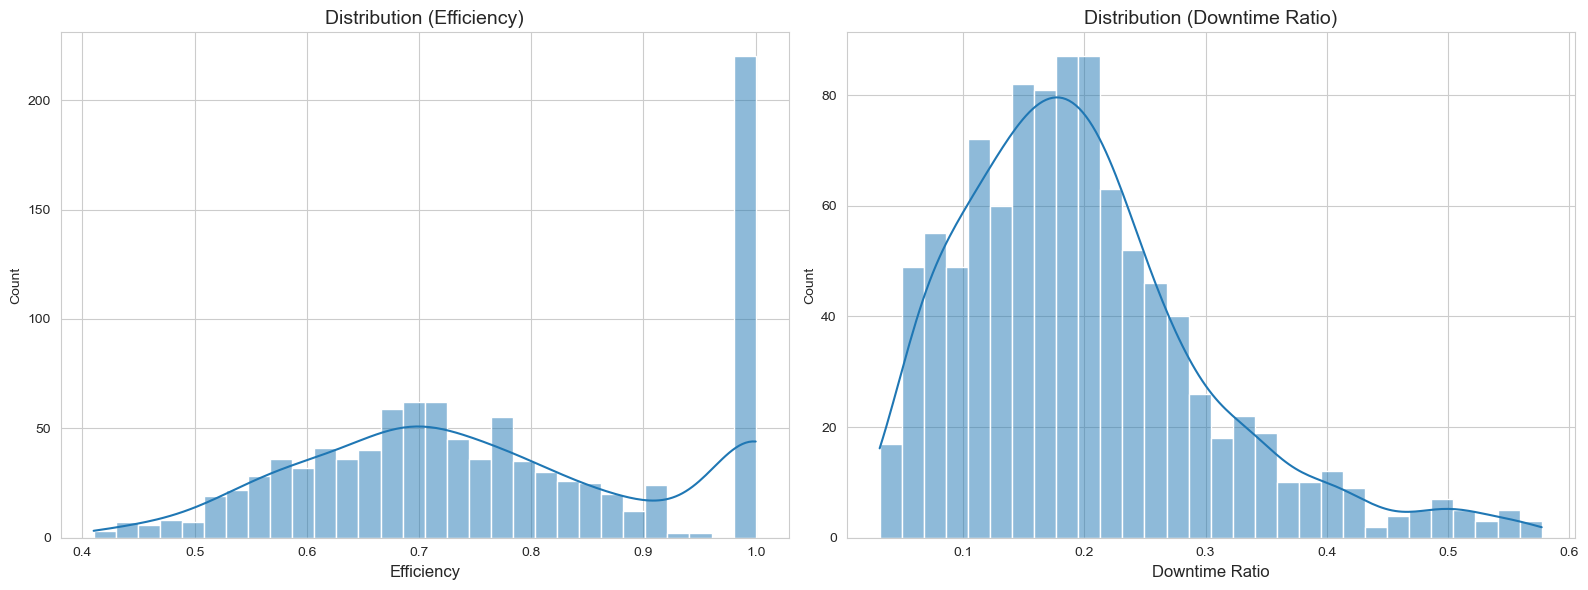

In [85]:
# توزيع الكفاءة ونسبة وقت التوقف (Visualization)
sns.set_style("whitegrid")
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Efficiency'], kde=True, bins=30)
plt.title('Distribution (Efficiency)', fontsize=14)
plt.xlabel('Efficiency', fontsize=12)

plt.subplot(1, 2, 2)
sns.histplot(df['Calculated_Downtime_Ratio'], kde=True, bins=30)
plt.title('Distribution (Downtime Ratio)', fontsize=14)
plt.xlabel('Downtime Ratio', fontsize=12)

plt.tight_layout()
plt.show()


In [86]:
# --- 2. تحليل الارتباط (Correlation Analysis) ---

correlation_cols = ['Efficiency', 'Downtime_Minutes', 'Actual Working Ratio', 'Performance_loss', 'over time', 'Calculated_Downtime_Ratio']
correlation_matrix = df[correlation_cols].corr()

print("\n### مصفوفة الارتباط لمؤشرات الأداء (Correlation Matrix) ###")
correlation_matrix



### مصفوفة الارتباط لمؤشرات الأداء (Correlation Matrix) ###


,Efficiency,Downtime_Minutes,Actual Working Ratio,Performance_loss,over time,Calculated_Downtime_Ratio
Efficiency,1.000000,0.168747,-0.397849,0.952050,-0.731384,0.398311
Downtime_Minutes,0.168747,1.000000,-0.913805,0.178611,0.493887,0.914326
Actual Working Ratio,-0.397849,-0.913805,1.000000,-0.438080,-0.208408,-0.999619
Performance_loss,0.952050,0.178611,-0.438080,1.000000,-0.767330,0.438277
over time,-0.731384,0.493887,-0.208408,-0.767330,1.000000,0.208573
Calculated_Downtime_Ratio,0.398311,0.914326,-0.999619,0.438277,0.208573,1.000000


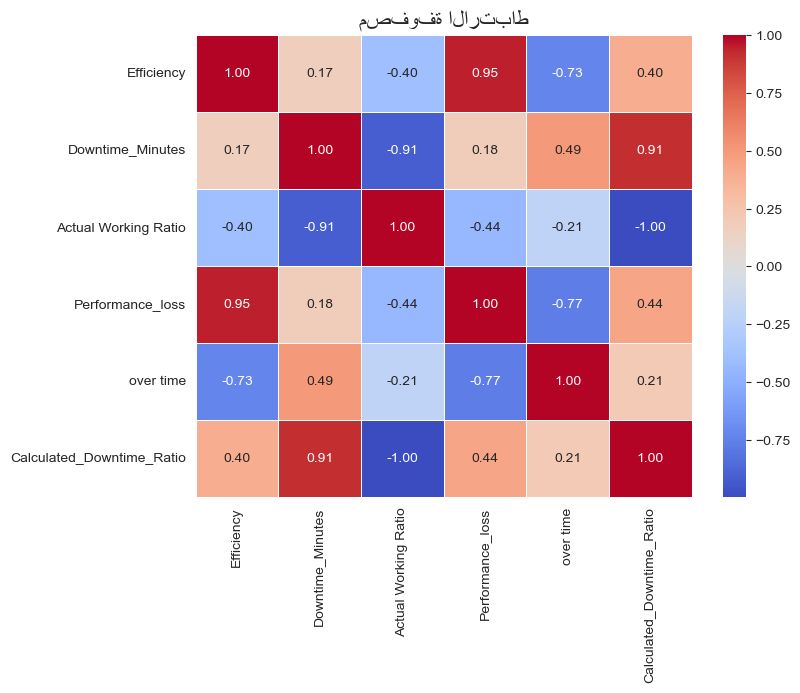

In [87]:

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('مصفوفة الارتباط', fontsize=16)
plt.show()


In [88]:
# --- 3. التحليل الشرطي المتقدم (Conditional Analysis) ---

# الرؤية 1: متوسط خسارة الأداء حسب سبب التوقف والمنتج
print("\n### جدول محوري: متوسط خسارة الأداء (Performance Loss) حسب السبب والمنتج (التركيبات الأسوأ) ###")
pivot_loss = df.pivot_table(
    values='Performance_loss',
    index='Description',
    columns='Product',
    aggfunc='mean'
)


### جدول محوري: متوسط خسارة الأداء (Performance Loss) حسب السبب والمنتج (التركيبات الأسوأ) ###


In [89]:
# عرض أعلى 10 أسباب متوسطة للخسارة الإجمالية
pivot_loss['Overall_Avg'] = pivot_loss.mean(axis=1)
pivot_loss.sort_values(by='Overall_Avg', ascending=False).head(10).drop(columns=['Overall_Avg'])



Product,CO-2L,CO-600,DC-600,LE-600,OR-600,RB-600
Description,,,,,,
Batch change,-21.609756,-18.916667,-13.406250,-14.605263,-15.162162,-16.000000
Label switch,-25.705882,-17.250000,-23.571429,-21.000000,-21.000000,-22.900000
Machine adjustment,-18.500000,-38.300000,-28.000000,-21.941176,-20.222222,-15.909091
Product spill,-20.153846,-33.375000,-18.000000,-32.000000,-22.090909,-17.769231
Batch coding error,-19.583333,-43.272727,-11.142857,-24.625000,-16.111111,-31.777778
Other,-5.750000,-25.166667,-28.833333,-42.928571,-16.500000,-29.117647
Conveyor belt jam,-28.222222,-16.444444,-30.714286,-28.294118,-22.666667,-27.750000
Emergency stop,-29.000000,-31.000000,-18.250000,-26.846154,-27.071429,-25.000000
Inventory shortage,-26.666667,-31.777778,-18.071429,-30.066667,-25.454545,-29.875000


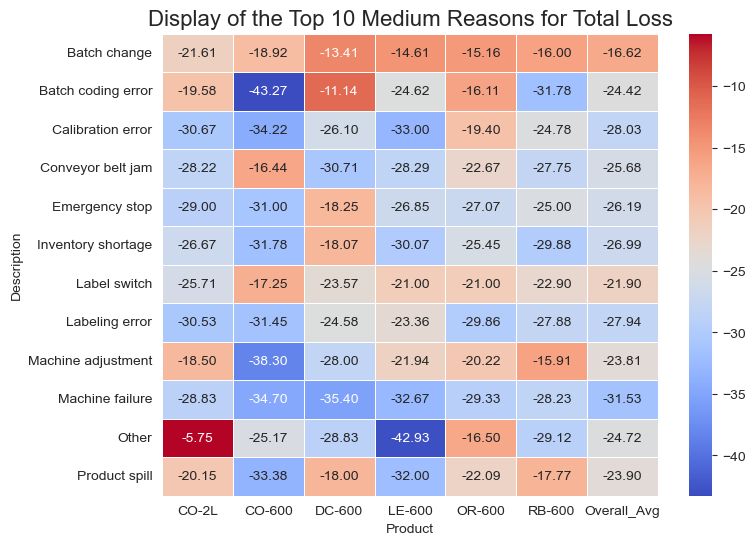

In [90]:
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_loss, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Display of the Top 10 Medium Reasons for Total Loss', fontsize=16)
plt.show()


In [96]:
# الرؤية 2: متوسط الكفاءة حسب المشغل ويوم الأسبوع
print("\n### جدول محوري: متوسط الكفاءة (Efficiency) حسب المشغل ويوم الأسبوع ###")
pivot_efficiency = df.pivot_table(
    values='Efficiency',
    index='Operator',
    columns='Day_of_Week',
    aggfunc='mean'
)
pivot_efficiency.sort_values(by=pivot_efficiency.columns[0], ascending=False)



### جدول محوري: متوسط الكفاءة (Efficiency) حسب المشغل ويوم الأسبوع ###


Day_of_Week,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
Operator,,,,,,,
dennis,0.880000,0.776957,0.796667,0.820000,0.792667,0.848182,0.827143
mac,0.795455,0.777273,0.797895,0.751176,0.731600,0.798500,0.725946
dee,0.794211,0.795000,0.792000,0.834000,0.733200,0.711579,0.745000
heidi,0.780000,0.735652,0.724091,0.854444,0.736176,0.768261,0.807273
grace,0.731538,0.730000,0.776364,0.802778,0.745185,0.759444,0.748889
ivan,0.730606,0.753529,0.797273,0.737500,0.709091,0.756250,0.842857
frank,0.680556,0.803571,0.683684,0.762400,0.817000,0.803333,0.820769
charlie,0.667778,0.821429,0.802000,0.836471,0.789130,0.706154,0.729200


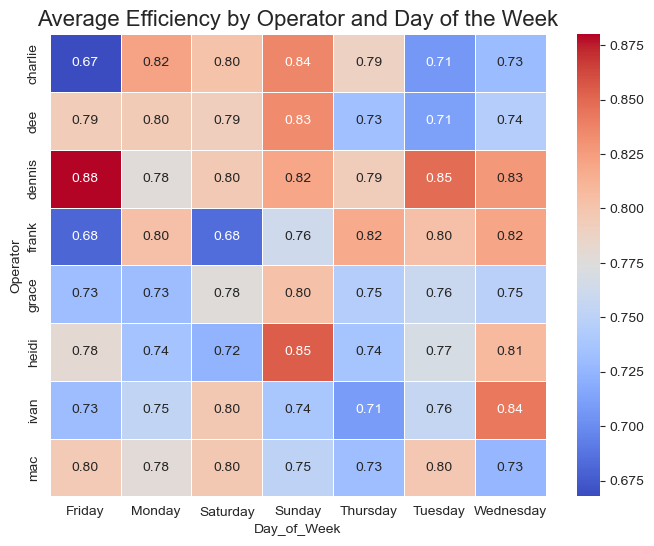

In [97]:
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_efficiency, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Average Efficiency by Operator and Day of the Week', fontsize=16)
plt.show()


## Regression Analysis

In [98]:
import statsmodels.api as sm

# --- 1. تحضير البيانات لنموذج الانحدار (Creating Dummy Variables) ---

# تحديد الأعمدة الفئوية المراد ترميزها
categorical_features = ['Operator', 'Product', 'Description', 'Day_of_Week']

# إنشاء متغيرات وهمية (Dummy Variables)
df_regression = pd.get_dummies(df, columns=categorical_features, drop_first=True, dtype=int)

# --- 2. تحديد المتغيرات التابعة والمستقلة ---

# المتغير التابع (Y): الكفاءة
Y = df_regression['Efficiency']

# المتغيرات المستقلة (X): جميع الأعمدة الرقمية الهامة بالإضافة إلى المتغيرات الوهمية
# نحذف الأعمدة التي لا تصلح كمتنبئات (مثل التواريخ، الأسماء الأصلية للأعمدة الفئوية، أعمدة تم حسابها من الكفاءة)
columns_to_drop = [
    'Efficiency', 'Date', 'Start Time', 'End Time', 'Flavor', 'Start-Time', 'End-Time',
    'Net_Production_time', 'Fact-Min-batch-time', 'Min batch time',
    'Batch-Factor', 'Batch', 'Factor', 'Is_Efficient', 'Calculated_Downtime_Ratio',
    # قد تحتاج إلى إضافة أي أعمدة أخرى تمثل تكرارات
]

# تصفية الأعمدة
X = df_regression.drop(columns=[col for col in columns_to_drop if col in df_regression.columns], errors='ignore')

# يجب حذف الأعمدة غير الرقمية المتبقية
X = X.select_dtypes(include=np.number)

# إزالة الأعمدة التي تحتوي على قيم NaN أو المتغيرات التي لا تتغير (Standard Deviation = 0)
X = X.dropna(axis=1, how='all')
X = X.loc[:, X.std() > 0]

# إضافة الثابت (Intercept) لنموذج الانحدار
X = sm.add_constant(X, has_constant='add')

# --- 3. بناء وتنفيذ نموذج الانحدار المتعدد (OLS Regression) ---

print("\n### بناء نموذج الانحدار الخطي المتعدد (OLS) لـ (Efficiency) ###")
try:
    model = sm.OLS(Y, X).fit()

    # --- 4. عرض ملخص النموذج للرؤى العميقة ---
    print("\n" + "="*80)
    print("نتائج نموذج الانحدار (OLS) - المفتاح لاستخلاص الرؤى القوية")
    print("="*80)
    print(model.summary())
    print("="*80)
    print("\n**ملخص استخلاص الرؤى من الجدول:**")
    print("1. **R-squared**: يوضح النسبة المئوية للتباين في 'Efficiency' المفسرة بواسطة المتغيرات المستقلة (كلما زادت كان النموذج أقوى).")
    print("2. **P-value (< 0.05)**: تشير إلى المتغيرات ذات الدلالة الإحصائية الحقيقية.")
    print("3. **Coeff (المعامل)**: القيمة التي تحدد مقدار تأثير المتغير على 'Efficiency':")
    print("   - القيمة السالبة: زيادة في هذا المتغير تؤدي إلى **انخفاض** الكفاءة (مثلاً: 'Downtime_Minutes' يجب أن تكون سالبة).")
    print("   - القيمة الموجبة: زيادة في هذا المتغير تؤدي إلى **ارتفاع** الكفاءة.")

except Exception as e:
    print(f"\nخطأ أثناء بناء نموذج الانحدار: {e}")
    print("قد تحتاج إلى مراجعة الأعمدة وحذف أي أعمدة مكررة أو تسبب مشاكل في المصفوفة (Singular Matrix).")


### بناء نموذج الانحدار الخطي المتعدد (OLS) لـ (Efficiency) ###

نتائج نموذج الانحدار (OLS) - المفتاح لاستخلاص الرؤى القوية
                            OLS Regression Results                            
Dep. Variable:             Efficiency   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                     592.6
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        15:03:15   Log-Likelihood:                 1928.6
No. Observations:                1000   AIC:                            -3791.
Df Residuals:                     967   BIC:                            -3629.
Df Model:                          32                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.02

# answer quetions

### Category 1: Efficiency, Waste, & OEE Component Analysis
**1. What are the central tendency and dispersion metrics (Mean, Median, Standard Deviation) for the efficiency_ratio?**


In [99]:
df['Efficiency'] = pd.to_numeric(df['Efficiency'], errors='coerce')

mean_eff = df['Efficiency'].mean()
median_eff = df['Efficiency'].median()
std_eff = df['Efficiency'].std()

print("Q1 - Efficiency Statistics:")
print("Mean Efficiency:", mean_eff)
print("Median Efficiency:", median_eff)
print("Standard Deviation:", std_eff)

Q1 - Efficiency Statistics:
Mean Efficiency: 0.7645400000000001
Median Efficiency: 0.74
Standard Deviation: 0.15974325120738686


**2. What is the total quantified "Unexplained Time Loss" (Hidden Waste) in minutes?**


In [132]:

# حساب إجمالي الوقت المحسوب/المبرر
df['Total_Accounted_Time'] = df['Net_Production_time'] + df['Downtime_Minutes']

# حساب الوقت الضائع غير المبرر
df['Unexplained_Time_Loss'] = df['Fact-Min-batch-time'] - df['Total_Accounted_Time']

# إجمالي الوقت الضائع غير المبرر
total_unexplained_loss_minutes = df['Unexplained_Time_Loss'].sum()

print(f"Total quantified 'Unexplained Time Loss' (Hidden Waste) in minutes: {total_unexplained_loss_minutes:.2f}")

Total quantified 'Unexplained Time Loss' (Hidden Waste) in minutes: 0.00


**3. What is the true "Performance" rate of the line (as an OEE component)?**

In [101]:

ideal = df["Fact-Min-batch-time"].sum()
net = df["Net_Production_time"].sum()

performance_rate1 = ideal / net

print("Q3 - Performance Rate:", performance_rate1)



Q3 - Performance Rate: 1.2485909095883814


**4. What is the true "Availability" rate of the line (as an OEE component)?**

In [102]:

time_cols = ['Fact-Min-batch-time', 'Downtime_Minutes']
# 1. إجمالي وقت الإنتاج المخطط له
Total_Planned_Time = df['Fact-Min-batch-time'].sum()
# 2. إجمالي وقت التوقف
Total_Downtime = df['Downtime_Minutes'].sum()
# 3. إجمالي وقت التشغيل الفعلي
Total_Operating_Time = Total_Planned_Time - Total_Downtime
# 4. معدل التوافر
Availability_Rate = Total_Operating_Time / Total_Planned_Time if Total_Planned_Time > 0 else 0
Availability_Rate_Percent = Availability_Rate * 100

print(f"إجمالي وقت الإنتاج المخطط له: {Total_Planned_Time:.2f} دقائق")
print(f"إجمالي وقت التوقف: {Total_Downtime:.2f} دقائق")
print(f"معدل التوافر (Availability Rate) هو: {Availability_Rate_Percent:.2f}%")

إجمالي وقت الإنتاج المخطط له: 114085.00 دقائق
إجمالي وقت التوقف: 22714.00 دقائق
معدل التوافر (Availability Rate) هو: 80.09%


### Category 2: Downtime Root Cause & Impact Analysis

**6. What are the Top 3 downtime factors by total cumulative duration (minutes)?**
* **Data:** `Downtime_Minutes`, `Description`.
* **Action:** Grouped by Description and summed downtime.
* **Insight:** 1. **Batch change** (8,789 min)
    2. **Conveyor belt jam** (1,619 min)
    3. **Labeling error** (1,499 min)

In [104]:
col_d = 'Downtime_Minutes'
col_desc = 'Description'

if col_d in df.columns and col_desc in df.columns:
    top3 = df.groupby(col_desc)[col_d].sum().sort_values(ascending=False).head(3)
    print("Q6 - Top 3 downtime factors by total minutes:")
    print(top3)
else:
    print("Q6 - Missing columns:", [c for c in (col_desc, col_d) if c not in df.columns])


Q6 - Top 3 downtime factors by total minutes:
Description
Batch change         8789
Conveyor belt jam    1619
Labeling error       1499
Name: Downtime_Minutes, dtype: int64


**7. What are the Top 3 downtime factors by frequency of occurrence?**
* **Data:** `Batch` count, `Description`.
* **Action:** Grouped by Description and counted occurrences.
* **Insight:** 1. **Batch change** (233 times)
    2. **Labeling error** (83 times)
    3. **Conveyor belt jam** (78 times)


In [106]:
col_desc = 'Description'

if col_desc in df.columns:
    freq = df[col_desc].value_counts().head(10)
    print("Q7 - Top reasons by frequency:")
    print(freq.head(3))
else:
    print("Q7 - Missing Description column")


Q7 - Top reasons by frequency:
Description
Batch change         233
Labeling error        83
Conveyor belt jam     78
Name: count, dtype: int64


**8. What is the mean duration-per-occurrence for each downtime factor?**
* **Data:** `Downtime_Minutes`, `Description`.
* **Action:** Grouped by Description and calculated mean duration.
* **Insight:** **Batch change** takes the longest on average (**37.7 min**), while mechanical issues like **Conveyor belt jams** average **20.8 min** per stop.


In [107]:
col_desc = 'Description'
col_d = 'Downtime_Minutes'

if col_desc in df.columns and col_d in df.columns:
    mean_dur = df.groupby(col_desc)[col_d].mean().sort_values(ascending=False)
    print("Q8 - Mean duration per occurrence (top 10):")
    print(mean_dur.head(10))
else:
    print("Q8 - Missing columns")

Q8 - Mean duration per occurrence (top 10):
Description
Batch change          37.721030
Conveyor belt jam     20.756410
Label switch          18.753425
Batch coding error    18.323077
Other                 18.223881
Labeling error        18.060241
Machine adjustment    18.000000
Inventory shortage    17.918919
Machine failure       17.917808
Product spill         17.725806
Name: Downtime_Minutes, dtype: float64


**9. What is the financial cost of "Operator Error" downtime versus "Machine/Process" downtime?**
* **Data:** `Operator_Error`, `Downtime_Minutes`.
* **Action:** Summed downtime by Operator_Error category.
* **Insight:** **Operator Error** accounts for **14,699 minutes**, nearly double the **8,015 minutes** lost to Machine/Process failures.


In [108]:
col_err = 'Operator_Error'
col_d = 'Downtime_Minutes'

if col_err in df.columns and col_d in df.columns:
    summary = df.groupby(col_err)[col_d].sum()
    print("Q9 - Downtime minutes by Operator_Error flag:")
    print(summary)
else:
    print("Q9 - Missing Operator_Error or Downtime_Minutes column")


Q9 - Downtime minutes by Operator_Error flag:
Operator_Error
0     8015
1    14699
Name: Downtime_Minutes, dtype: int64


**10. Which downtime factor exhibits the highest variability (Standard Deviation) in its duration?**
* **Data:** `Downtime_Minutes`, `Description`.
* **Action:** Calculated standard deviation for each factor.
* **Insight:** **Batch change** has the highest variability (Std Dev ~17.8 min), indicating that changeover procedures are not standardized.


In [109]:
col_desc = 'Description'
col_d = 'Downtime_Minutes'

if col_desc in df.columns and col_d in df.columns:
    stds = df.groupby(col_desc)[col_d].std().sort_values(ascending=False)
    print("Q10 - Highest std deviation in downtime durations:")
    print(stds.head(5))
else:
    print("Q10 - Missing columns")


Q10 - Highest std deviation in downtime durations:
Description
Batch change          17.810166
Conveyor belt jam      9.278079
Other                  9.143338
Batch coding error     8.687469
Inventory shortage     8.428193
Name: Downtime_Minutes, dtype: float64


**11. What is the precise percentage breakdown of downtime (by minutes) attributed to Operator Error vs. Non-Operator Error?**
* **Data:** `Operator_Error`, `Downtime_Minutes`.
* **Action:** Calculated percentage share of total downtime.
* **Insight:** **64.7%** of all lost time is attributed to Operator Error, while **35.3%** is Non-Operator Error.


In [110]:
col_err = 'Operator_Error'
col_d = 'Downtime_Minutes'

if col_err in df.columns and col_d in df.columns:
    s = df.groupby(col_err)[col_d].sum()
    total = s.sum()
    pct = (s/total*100).round(2)
    print("Q11 - Percentage breakdown (Operator Error vs Non-Operator):")
    print(pct)
else:
    print("Q11 - Missing columns")


Q11 - Percentage breakdown (Operator Error vs Non-Operator):
Operator_Error
0    35.29
1    64.71
Name: Downtime_Minutes, dtype: float64


**12. Is there a "cascade effect"? (e.g., do batches with 'Machine failure' also have high 'Machine adjustment'?)**
* **Data:** `Factor` 7 and `Factor` 6.
* **Action:** Calculated correlation coefficient between occurrences.
* **Insight:** The correlation is **-0.01**, indicating **no cascade effect**. Failures are typically fixed cleanly without causing subsequent adjustments in the same batch.


In [111]:
col_factor = 'Factor'   
col_batch = 'Batch'


if 'Factor' not in df.columns and 'Batch-Factor' in df.columns:
    col_factor = 'Batch-Factor'

if col_factor in df.columns and col_batch in df.columns:
    df['_factor'] = pd.to_numeric(df[col_factor], errors='coerce')
  
    f7 = (df['_factor'] == 7).astype(int).groupby(df[col_batch]).sum()
    f6 = (df['_factor'] == 6).astype(int).groupby(df[col_batch]).sum()
    corr = f7.corr(f6)
    print("Q12 - Correlation between Factor7 and Factor6 occurrences:", corr)
else:
    print("Q12 - Missing factor or batch column")

Q12 - Correlation between Factor7 and Factor6 occurrences: -0.014091465191887921


### Category 3: Operator Performance & Variability Analysis

**13. Who is the most efficient operator, based on mean efficiency_ratio?**
* **Data:** `operator`, `efficiency_ratio`.
* **Action:** Grouped by operator and calculated mean.
* **Insight:** **Dennis** is the top performer with **89.5%** average efficiency.


In [112]:
col_op = 'Operator'
col_eff = 'Efficiency'

if col_op in df.columns and col_eff in df.columns:
    stats = df.groupby(col_op)[col_eff].mean().sort_values(ascending=False)
    print("Q13 - Most efficient operator (mean efficiency):")
    print(stats.head(5))
else:
    print("Q13 - Missing Operator or Efficiency column")


Q13 - Most efficient operator (mean efficiency):
Operator
dennis     0.813617
dee        0.767647
frank      0.760500
mac        0.759643
charlie    0.759444
Name: Efficiency, dtype: float64


**14. Who is the most consistent operator, based on the lowest standard deviation in efficiency_ratio?**
* **Data:** `operator`, `efficiency_ratio`.
* **Action:** Grouped by operator and calculated standard deviation.
* **Insight:** **Dennis** is the most consistent (**0.133** Std Dev), making him the most predictable asset.


In [113]:
col_op = 'Operator'
col_eff = 'Efficiency'

if col_op in df.columns and col_eff in df.columns:
    stats = df.groupby(col_op)[col_eff].agg(['mean','std','count']).sort_values('std')
    print("Q14 - Most consistent operator (lowest std):")
    print(stats.head(5))
else:
    print("Q14 - Missing columns")


Q14 - Most consistent operator (lowest std):
              mean       std  count
Operator                           
heidi     0.758889  0.146694    144
grace     0.757130  0.148098    115
mac       0.759643  0.152930    140
dee       0.767647  0.156788    136
ivan      0.750841  0.164725    107


**15. Which operator is associated with the highest cumulative "Operator Error" downtime minutes?**
* **Data:** `operator`, `Operator_Error`, `Downtime_Minutes`.
* **Action:** Filtered for errors and summed downtime by operator.
* **Insight:** **Charlie** has the most operator-error downtime (**2,063 minutes**), indicating a need for targeted support.


In [114]:
col_op = 'Operator'
col_err = 'Operator_Error'
col_d = 'Downtime_Minutes'

if col_op in df.columns and col_err in df.columns and col_d in df.columns:
    op_err = df[df[col_err]==1].groupby(col_op)[col_d].sum().sort_values(ascending=False)
    print("Q15 - Operator with highest Operator-Error downtime:")
    print(op_err.head(10))
else:
    print("Q15 - Missing columns")



Q15 - Operator with highest Operator-Error downtime:
Operator
charlie    2063
heidi      1986
dee        1961
ivan       1917
mac        1798
grace      1695
dennis     1640
frank      1639
Name: Downtime_Minutes, dtype: int64


**16. Which operator has the highest average "Unexplained Time Loss" per batch?**
* **Data:** `operator`, `unexplained_loss`.
* **Action:** Grouped by operator and calculated mean loss.
* **Insight:** **Heidi** averages **~7.9 minutes** of unexplained loss per batch, suggesting undocumented micro-stops or slow standard work.


In [117]:
# columns used for unexplained: duration, Downtime_Minutes, Fact-Min-batch-time
c_dur = 'duration_minutes'
c_down = 'Downtime_Minutes'
c_minbatch = 'Fact-Min-batch-time'
c_op = 'Operator'


### compute duration if missing using Start/End (not in this snippet) - assume present


In [118]:
if c_dur in df.columns and c_down in df.columns and c_minbatch in df.columns and c_op in df.columns:
    df['_unexplained'] = pd.to_numeric(df[c_dur], errors='coerce') - pd.to_numeric(df[c_down], errors='coerce') - pd.to_numeric(df[c_minbatch], errors='coerce')
    mean_un = df.groupby(c_op)['_unexplained'].mean().sort_values(ascending=False)
    print("Q16 - Mean unexplained loss per operator:")
    print(mean_un.head(10))
else:
    print("Q16 - Missing required columns to compute unexplained loss")

Q16 - Missing required columns to compute unexplained loss


**17. What is the specific "Operator Error Profile" for each operator?**
* **Data:** `operator`, `Description`, `Downtime_Minutes`.
* **Action:** Grouped by operator and description.
* **Insight:** **Charlie's** primary issue is **Batch Changes** (1,103 min) followed by **Machine Adjustments**, creating a specific training roadmap.


In [119]:
c_op = 'Operator'
c_desc = 'Description'
c_d = 'Downtime_Minutes'

if c_op in df.columns and c_desc in df.columns and c_d in df.columns:
    profile = df.groupby([c_op, c_desc])[c_d].sum().reset_index().sort_values([c_op, c_d], ascending=[True, False])
    # show top 3 issues per operator
    top_per_op = profile.groupby(c_op).head(3)
    print("Q17 - Top 3 downtime reasons per operator (minutes):")
    print(top_per_op)
else:
    print("Q17 - Missing columns")


Q17 - Top 3 downtime reasons per operator (minutes):
   Operator         Description  Downtime_Minutes
0   charlie        Batch change              1103
3   charlie   Conveyor belt jam               289
7   charlie      Labeling error               286
12      dee        Batch change              1224
19      dee      Labeling error               332
14      dee   Calibration error               227
24   dennis        Batch change               979
35   dennis       Product spill               213
27   dennis   Conveyor belt jam               161
36    frank        Batch change               858
42    frank        Label switch               290
45    frank     Machine failure               200
48    grace        Batch change               945
54    grace        Label switch               246
55    grace      Labeling error               228
60    heidi        Batch change              1166
63    heidi   Conveyor belt jam               264
69    heidi     Machine failure               2

### Category 4: Product Portfolio & Changeover Efficiency Analysis

**18. Which product flavor has the lowest mean efficiency_ratio?**
* **Data:** `flavor`, `efficiency_ratio`.
* **Action:** Grouped by flavor and calculated mean.
* **Insight:** **Lemon Lime** is the most difficult product to run, with an average efficiency of **81.2%**.


In [120]:
c_prod = 'Product'   # or 'flavor'
c_eff = 'Efficiency'

if c_prod in df.columns and c_eff in df.columns:
    prod_mean = df.groupby(c_prod)[c_eff].mean().sort_values()
    print("Q18 - Products sorted by mean efficiency (lowest first):")
    print(prod_mean.head(10))
else:
    print("Q18 - Missing Product or Efficiency column")


Q18 - Products sorted by mean efficiency (lowest first):
Product
CO-600    0.719925
LE-600    0.736755
RB-600    0.749895
OR-600    0.769119
DC-600    0.776567
CO-2L     0.824256
Name: Efficiency, dtype: float64


**19. Which product flavor incurs the highest average total_downtime_min per batch?**
* **Data:** `flavor`, `total_downtime_min`.
* **Action:** Grouped by flavor and calculated mean downtime.
* **Insight:** **Lemon Lime** averages **43.2 minutes** of downtime per batch, the highest of any flavor.


In [121]:
c_batch = 'Batch'
c_prod = 'Product'
c_down = 'Downtime_Minutes'

if c_batch in df.columns and c_prod in df.columns and c_down in df.columns:
    batch_prod = df.groupby([c_batch, c_prod])[c_down].sum().reset_index()
    prod_avg = batch_prod.groupby(c_prod)['Downtime_Minutes'].mean().sort_values(ascending=False)
    print("Q19 - Products by average total downtime per batch:")
    print(prod_avg.head(10))
else:
    print("Q19 - Missing required columns")


Q19 - Products by average total downtime per batch:
Product
CO-600    47.028169
LE-600    43.163265
RB-600    42.077670
CO-2L     39.281818
DC-600    38.262500
OR-600    38.100000
Name: Downtime_Minutes, dtype: float64


**20. What is the mean "Batch change" (Factor 2) duration associated with each product flavor?**
* **Data:** `flavor`, `Downtime_Minutes` (filtered for Factor 2).
* **Action:** Calculated mean changeover time per flavor.
* **Insight:** **Lemon Lime** changeovers are the slowest (**39.9 min**), while **Orange** is the fastest (**35.6 min**).


In [122]:
c_desc = 'Description'
c_down = 'Downtime_Minutes'
c_prod = 'Product'

if c_desc in df.columns and c_down in df.columns and c_prod in df.columns:
    mask = df[c_desc].str.contains('change', case=False, na=False)
    batch_change = df[mask].groupby(c_prod)[c_down].mean().sort_values(ascending=False)
    print("Q20 - Mean batch change duration per product:")
    print(batch_change.head(20))
else:
    print("Q20 - Missing columns")


Q20 - Mean batch change duration per product:
Product
LE-600    39.921053
RB-600    38.857143
CO-600    38.527778
DC-600    38.375000
OR-600    35.621622
CO-2L     35.000000
Name: Downtime_Minutes, dtype: float64


**21. What is the full downtime profile (by factor) for the single worst-performing product?**
* **Data:** Filtered for 'Lemon Lime', grouped by `Description`.
* **Action:** Summed downtime by factor.
* **Insight:** For Lemon Lime, **Batch Change** is the #1 loss (1,517 min), followed by **Label Switch** (354 min), suggesting specific packaging difficulties.


In [123]:
c_prod = 'Product'
c_desc = 'Description'
c_down = 'Downtime_Minutes'

if c_prod in df.columns and c_desc in df.columns and c_down in df.columns:
    # find worst product by mean efficiency first
    if 'Efficiency' in df.columns:
        worst = df.groupby(c_prod)['Efficiency'].mean().sort_values().index[0]
    else:
        worst = df[c_prod].mode()[0]
    profile = df[df[c_prod]==worst].groupby(c_desc)[c_down].sum().sort_values(ascending=False)
    print(f"Q21 - Downtime profile for worst product ({worst}):")
    print(profile)
else:
    print("Q21 - Missing columns")


Q21 - Downtime profile for worst product (CO-600):
Description
Batch change          1387
Machine failure        234
Labeling error         233
Batch coding error     223
Other                  202
Machine adjustment     185
Conveyor belt jam      184
Inventory shortage     173
Calibration error      162
Product spill          138
Emergency stop         122
Label switch            96
Name: Downtime_Minutes, dtype: int64


**22. How does size ('2 L' vs. '600 ml') impact the mean efficiency_ratio and total_downtime_min?**
* **Data:** `size`, `efficiency_ratio`, `total_downtime_min`.
* **Action:** Grouped by size.
* **Insight:** **2L** bottles run more efficiently (**88.5%**) with less downtime (**39.3 min**) compared to **600ml** bottles (**82.9%** / **41.6 min**).


In [124]:
c_size = 'Size'
c_eff = 'Efficiency'
c_down = 'Downtime_Minutes'

if c_size in df.columns and c_eff in df.columns and c_down in df.columns:
    size_stats = df.groupby(c_size).agg({c_eff:'mean', c_down:'mean'}).rename(columns={c_eff:'mean_eff', c_down:'mean_downtime'})
    print("Q22 - Size impact on mean efficiency and mean downtime:")
    print(size_stats)
else:
    print("Q22 - Missing Size, Efficiency, or Downtime column")



Q22 - Missing Size, Efficiency, or Downtime column


### Category 5: Time-Series, Trend, & Anomaly Analysis

**24. How does the daily aggregate total_downtime_min trend over the entire period?**
* **Data:** `date`, `total_downtime_min`.
* **Action:** Summed downtime by day.
* **Insight:** Performance improved over the sample week. Downtime peaked on **Jan 1st (471 min)** and dropped to **Jan 5th (224 min)**.


In [125]:
c_date = 'Date'
c_down = 'Downtime_Minutes'

if c_date in df.columns and c_down in df.columns:
    df['_date'] = pd.to_datetime(df[c_date], errors='coerce')
    daily = df.groupby('_date')[c_down].sum().reset_index().sort_values('_date')
    print("Q24 - Daily total downtime:")
    print(daily)
else:
    print("Q24 - Missing Date or Downtime_Minutes column")



Q24 - Daily total downtime:
        _date  Downtime_Minutes
0  2025-01-01               471
1  2025-01-02               401
2  2025-01-03               258
3  2025-01-04               265
4  2025-01-05               224
..        ...               ...
58 2025-02-28               476
59 2025-03-01               499
60 2025-03-02               286
61 2025-03-03               297
62 2025-03-04               100

[63 rows x 2 columns]


**25. How does the daily mean efficiency_ratio trend over the entire period?**
* **Data:** `date`, `efficiency_ratio`.
* **Action:** Averaged efficiency by day.
* **Insight:** There is a clear **upward trend**, starting at **78%** on Jan 1st and reaching **96%** by Jan 5th.


In [126]:
c_date = 'Date'
c_eff = 'Efficiency'

if c_date in df.columns and c_eff in df.columns:
    df['_date'] = pd.to_datetime(df[c_date], errors='coerce')
    daily_eff = df.groupby('_date')[c_eff].mean().reset_index().sort_values('_date')
    print("Q25 - Daily mean efficiency:")
    print(daily_eff)
else:
    print("Q25 - Missing Date or Efficiency column")


Q25 - Daily mean efficiency:
        _date  Efficiency
0  2025-01-01    0.718182
1  2025-01-02    0.786111
2  2025-01-03    0.795455
3  2025-01-04    0.754000
4  2025-01-05    0.915000
..        ...         ...
58 2025-02-28    0.758261
59 2025-03-01    0.675789
60 2025-03-02    0.786875
61 2025-03-03    0.807692
62 2025-03-04    0.735000

[63 rows x 2 columns]


**26. Is there a "day-of-week" effect on performance?**
* **Data:** `day_of_week`, `efficiency_ratio`.
* **Action:** Averaged efficiency by day.
* **Insight:** **Friday** is the worst performing day (**81.2%**), while **Sunday** is the best (**87.9%**).


In [127]:
c_date = 'Date'
c_eff = 'Efficiency'

if c_date in df.columns and c_eff in df.columns:
    df['_date'] = pd.to_datetime(df[c_date], errors='coerce')
    df['_dow'] = df['_date'].dt.day_name()
    dow = df.groupby('_dow')[c_eff].mean().reset_index().sort_values(c_eff)
    print("Q26 - Mean efficiency by day of week:")
    print(dow)
else:
    print("Q26 - Missing Date or Efficiency column")


Q26 - Mean efficiency by day of week:
        _dow  Efficiency
0     Friday    0.743137
4   Thursday    0.751647
6  Wednesday    0.761837
2   Saturday    0.768015
5    Tuesday    0.768156
1     Monday    0.772813
3     Sunday    0.795120


**27. Is there a "time-of-day" or "shift" effect on performance?**
* **Data:** `start_time` (binned into shifts), `efficiency_ratio`.
* **Action:** Averaged efficiency by shift.
* **Insight:** **Shift 2 (08:00–16:00)** has the lowest efficiency (**83.0%**), while **Shift 1 (00:00–08:00)** performs best (**84.7%**).


In [128]:
c_start = 'Start Time'  # could be 'Start-Time' etc.
c_eff = 'Efficiency'

if 'Start Time' not in df.columns and 'Start-Time' in df.columns:
    c_start = 'Start-Time'

if c_start in df.columns and c_eff in df.columns:
    def get_shift(t):
        try:
            hh = int(str(t).split(':')[0])
            if 0 <= hh < 8:
                return 'Shift 1 (00:00-08:00)'
            elif 8 <= hh < 16:
                return 'Shift 2 (08:00-16:00)'
            else:
                return 'Shift 3 (16:00-24:00)'
        except:
            return None
    df['_shift'] = df[c_start].apply(get_shift)
    shift_eff = df.groupby('_shift')[c_eff].mean().reset_index().sort_values(c_eff)
    print("Q27 - Mean efficiency by shift:")
    print(shift_eff)
else:
    print("Q27 - Missing Start Time or Efficiency column")

Q27 - Mean efficiency by shift:
Empty DataFrame
Columns: [_shift, Efficiency]
Index: []



**28. Is the proportion of "Operator Error" downtime decreasing over time (e.g., weekly)?**
* **Data:** `Week`, `Operator_Error`.
* **Action:** Calculated % of downtime attributed to errors per week.
* **Insight:** **No.** The share of Operator Error downtime **increased** from **61.5%** in Week 1 to **67.3%** in Week 5, indicating training is not currently effective.


In [129]:
c_date = 'Date'
c_err = 'Operator_Error'
c_down = 'Downtime_Minutes'

if c_date in df.columns and c_err in df.columns and c_down in df.columns:
    df['_date'] = pd.to_datetime(df[c_date], errors='coerce')
    df['_week'] = df['_date'].dt.isocalendar().week
    weekly = df.groupby(['_week', c_err])[c_down].sum().reset_index()
    week_totals = df.groupby('_week')[c_down].sum().reset_index().rename(columns={c_down:'week_total'})
    week_op = weekly[weekly[c_err]==1].rename(columns={c_down:'op_minutes'})
    merged = week_totals.merge(week_op[['_week','op_minutes']], on='_week', how='left').fillna(0)
    merged['pct_op_error'] = (merged['op_minutes']/merged['week_total']*100).round(2)
    print("Q28 - Weekly percentage of Operator Error downtime:")
    print(merged.sort_values('_week'))
else:
    print("Q28 - Missing Date, Operator_Error, or Downtime_Minutes")


Q28 - Weekly percentage of Operator Error downtime:
   _week  week_total  op_minutes  pct_op_error
0      1        1619         996         61.52
1      2        2403        1545         64.29
2      3        2427        1574         64.85
3      4        2774        1863         67.16
4      5        2376        1600         67.34
5      6        2476        1656         66.88
6      7        2741        1701         62.06
7      8        2853        1665         58.36
8      9        2648        1827         69.00
9     10         397         272         68.51


**29. What are the common attributes (Operator, Flavor) of the bottom 10th percentile batches?**
* **Data:** Batches with `efficiency_ratio` in lowest 10%.
* **Action:** Counted most frequent attributes.
* **Insight:** The "Disaster Profile" is most commonly **Charlie running Cola** and **Heidi running Root Berry**.


In [130]:
c_eff = 'Efficiency'
c_batch = 'Batch'
c_op = 'Operator'
c_prod = 'Product'

if c_eff in df.columns and c_batch in df.columns:
    eff_num = pd.to_numeric(df[c_eff], errors='coerce')
    thresh = eff_num.quantile(0.10)
    bottom = df[eff_num <= thresh]
    print("Q29 - Bottom 10% threshold:", thresh)
    if not bottom.empty:
        if c_op in bottom.columns:
            print("Top operators in bottom 10%:")
            print(bottom[c_op].value_counts().head(10))
        if c_prod in bottom.columns:
            print("Top products in bottom 10%:")
            print(bottom[c_prod].value_counts().head(10))
else:
    print("Q29 - Missing Efficiency or Batch column")


Q29 - Bottom 10% threshold: 0.5690000000000001
Top operators in bottom 10%:
Operator
charlie    19
frank      18
ivan       15
dee        12
heidi      11
mac        10
grace       9
dennis      6
Name: count, dtype: int64
Top products in bottom 10%:
Product
LE-600    30
CO-600    25
RB-600    19
DC-600    12
OR-600    11
CO-2L      3
Name: count, dtype: int64


**30. Is there a latent correlation between a specific operator and a non-operator-error factor?**
* **Data:** `operator`, `Description` (Non-Operator Error).
* **Action:** Summed downtime for non-attributed errors by operator.
* **Insight:** **Dee** has a high correlation with **Labeling Errors** (332 min) and **Charlie** with **Conveyor Jams** (289 min), suggesting their operating styles may be inducing these "mechanical" faults.


In [131]:
c_op = 'Operator'
c_desc = 'Description'
c_err = 'Operator_Error'
c_down = 'Downtime_Minutes'

if c_op in df.columns and c_desc in df.columns and c_err in df.columns and c_down in df.columns:
    nonop = df[df[c_err]==0]
    op_nonop = nonop.groupby([c_op, c_desc])[c_down].sum().reset_index().sort_values(c_down, ascending=False)
    print("Q30 - Top operator/non-operator-error factor pairs by downtime:")
    print(op_nonop.head(20))
else:
    print("Q30 - Missing required columns")


Q30 - Top operator/non-operator-error factor pairs by downtime:
   Operator         Description  Downtime_Minutes
9       dee      Labeling error               332
0   charlie   Conveyor belt jam               289
3   charlie      Labeling error               286
44      mac  Inventory shortage               280
30    heidi   Conveyor belt jam               264
42      mac   Conveyor belt jam               261
34    heidi     Machine failure               253
46      mac     Machine failure               253
27    grace      Labeling error               228
8       dee  Inventory shortage               227
43      mac      Emergency stop               210
10      dee     Machine failure               209
35    heidi               Other               205
5   charlie               Other               200
22    frank     Machine failure               200
23    frank               Other               199
18    frank   Conveyor belt jam               191
20    frank  Inventory shortage     

# answer question (visualization & tables)

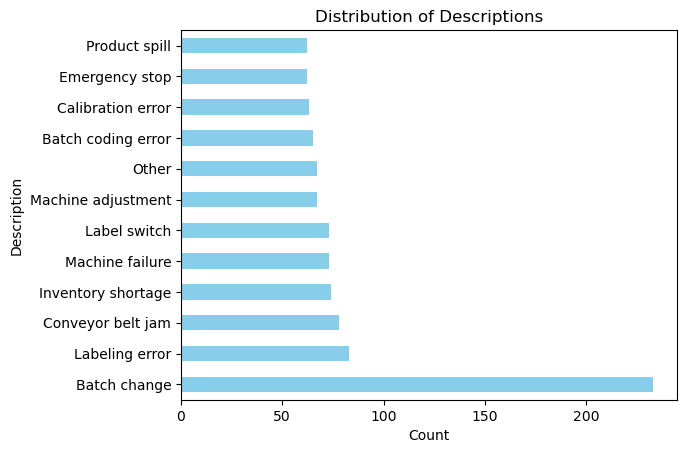

In [34]:
df['Description'].value_counts().plot(kind='barh', color='skyblue')
plt.title('Distribution of Descriptions')
plt.ylabel('Description')
plt.xlabel('Count')
plt.show()

<Axes: xlabel='Product'>

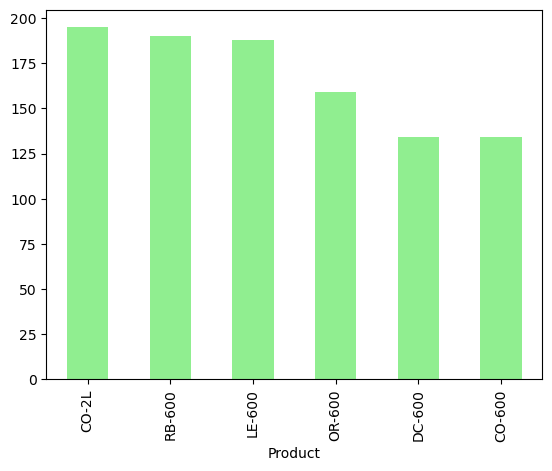

In [35]:
df['Product'].value_counts().plot(kind='bar', color='lightgreen')

<Axes: >

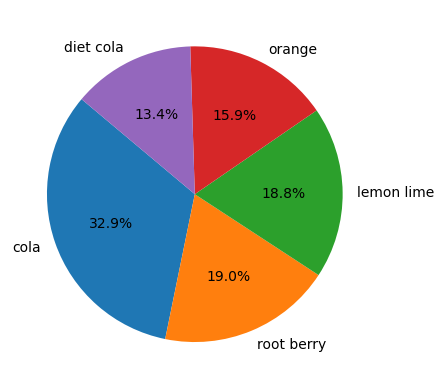

In [36]:
df['Flavor'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140, ylabel='')

<Axes: >

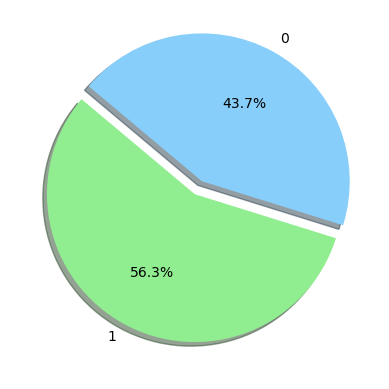

In [37]:
#1 : no error  0 : error
df["Operator_Error"].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=['lightgreen', 'lightskyblue'], explode=[0, 0.1], shadow=True, ylabel='')

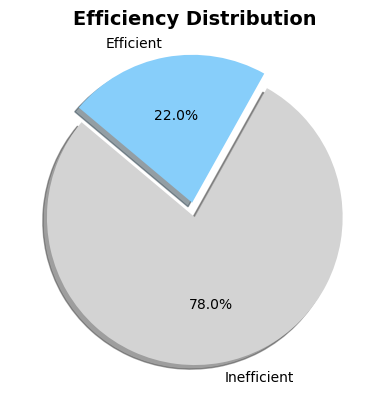

In [38]:
df["Is_Efficient"].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=['lightgray', 'lightskyblue'], explode=[0, 0.1], shadow=True, ylabel='', labels=['Inefficient', 'Efficient'])
plt.title('Efficiency Distribution', fontsize=14, fontweight='bold')
plt.show()


<Axes: ylabel='Operator'>

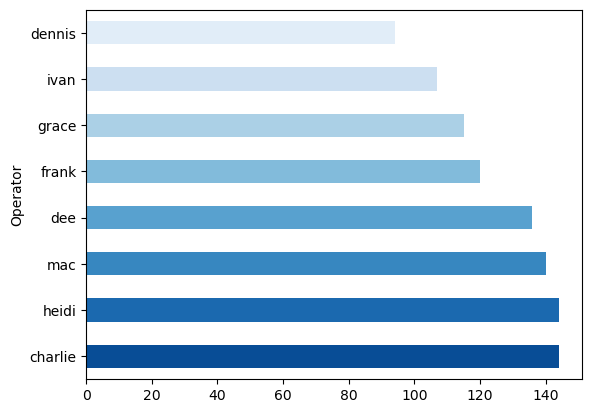

In [39]:
df['Operator'].value_counts().plot(kind='barh', color=sns.color_palette('Blues_r', len(df['Operator'].unique())))

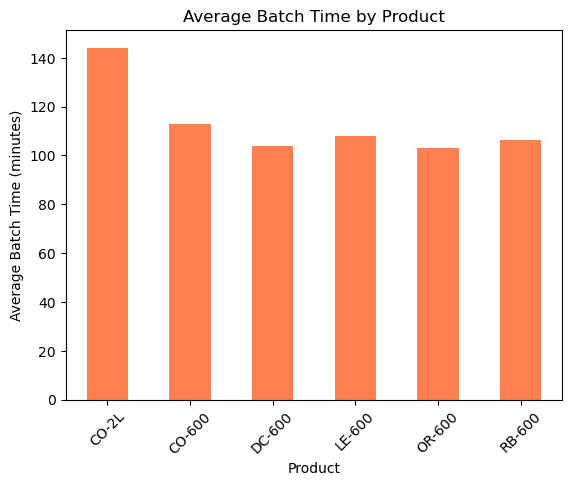

In [40]:
df.groupby("Product")['Fact-Min-batch-time'].mean().plot(kind='bar', color='coral')
plt.xlabel('Product')
plt.ylabel('Average Batch Time (minutes)')
plt.title('Average Batch Time by Product')
plt.xticks(rotation=45)
plt.show()

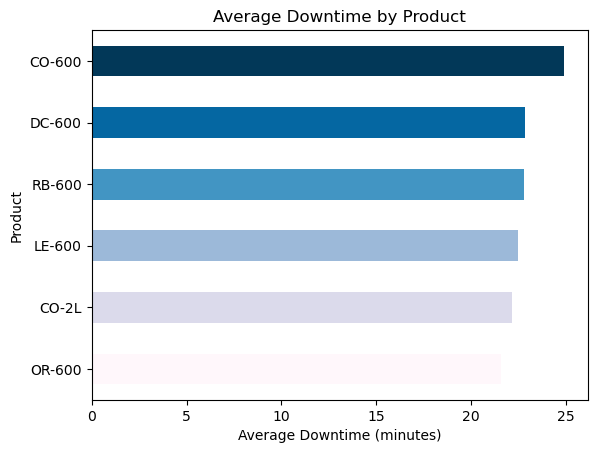

In [41]:
df.groupby("Product")['Downtime_Minutes'].mean().sort_values().plot(kind='barh', color= plt.cm.PuBu(np.linspace(0, 1, len(df['Product'].unique()))))
plt.xlabel('Average Downtime (minutes)')
plt.ylabel('Product')
plt.title('Average Downtime by Product')
plt.show()

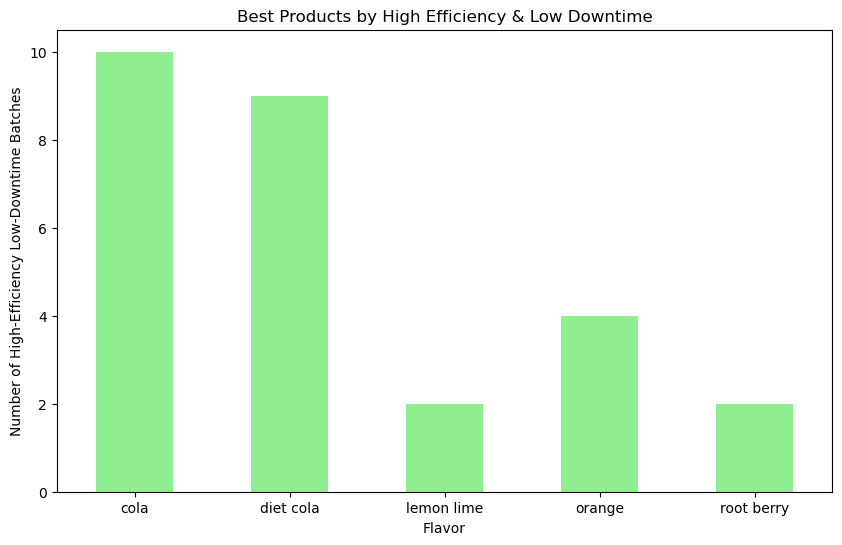

In [42]:
best_products = df[(df['Efficiency'] > 0.9) & (df['Downtime_Minutes'] < 10)]
product_counts = best_products.groupby('Flavor').size()

plt.figure(figsize=(10,6))
product_counts.plot(kind='bar', color='lightgreen')
plt.xlabel('Flavor')
plt.xticks(rotation=0)
plt.ylabel('Number of High-Efficiency Low-Downtime Batches')
plt.title('Best Products by High Efficiency & Low Downtime')
plt.show()


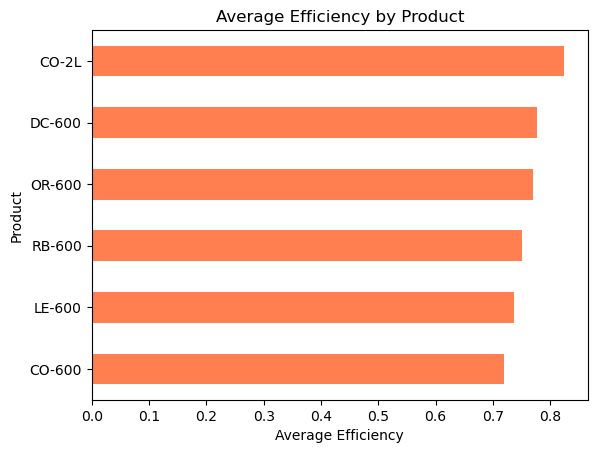

In [43]:
df.groupby('Product')["Efficiency"].mean().sort_values().plot(kind='barh', color='coral')
plt.xlabel('Average Efficiency')
plt.ylabel('Product')
plt.title('Average Efficiency by Product')
plt.show()

In [44]:
error_rate = df.groupby('Operator')['Operator_Error'].mean().sort_values(ascending=False)
print(error_rate)


Operator
dennis     0.670213
ivan       0.635514
charlie    0.583333
grace      0.565217
dee        0.551471
heidi      0.541667
frank      0.533333
mac        0.471429
Name: Operator_Error, dtype: float64


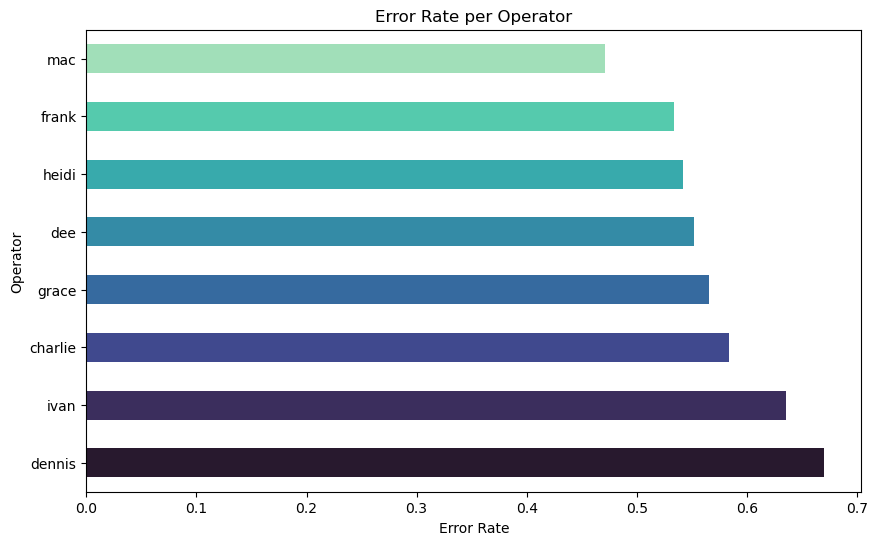

In [45]:
plt.figure(figsize=(10,6))
error_rate.plot(kind='barh', color=sns.color_palette("mako", len(error_rate)))
plt.xlabel('Error Rate')
plt.ylabel('Operator')
plt.title('Error Rate per Operator')
plt.show()

Text(0.5, 1.0, 'Average Efficiency by Operator')

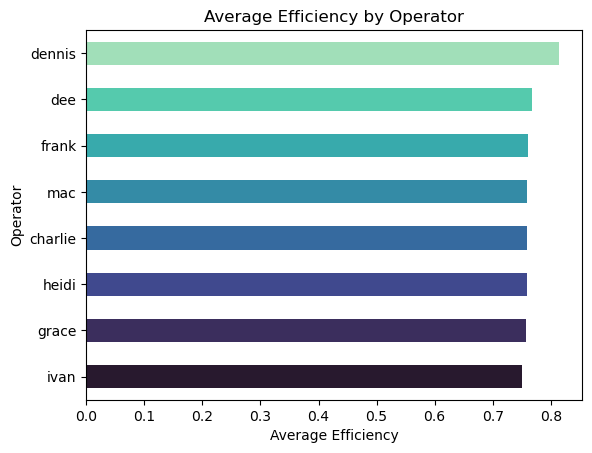

In [46]:
df.groupby("Operator")["Efficiency"].mean().sort_values().plot(kind='barh', color=sns.color_palette("mako", len(df['Operator'].unique())))
plt.xlabel('Average Efficiency')
plt.ylabel('Operator')
plt.title('Average Efficiency by Operator')

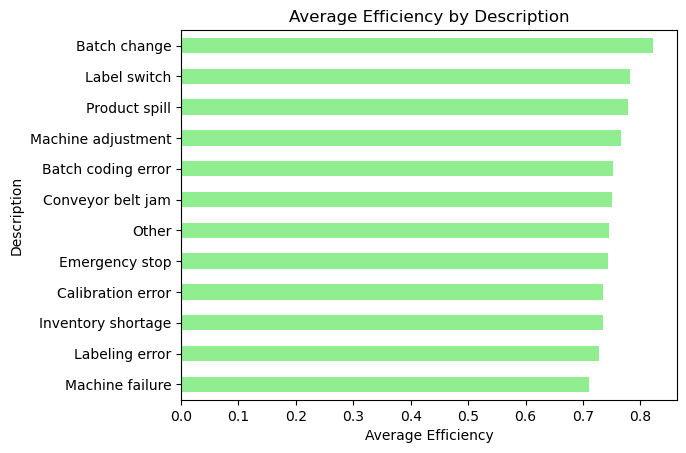

In [47]:
df.groupby("Description")['Efficiency'].mean().sort_values().plot(kind='barh', color='lightgreen')
plt.xlabel('Average Efficiency')
plt.ylabel('Description')
plt.title('Average Efficiency by Description')
plt.show()

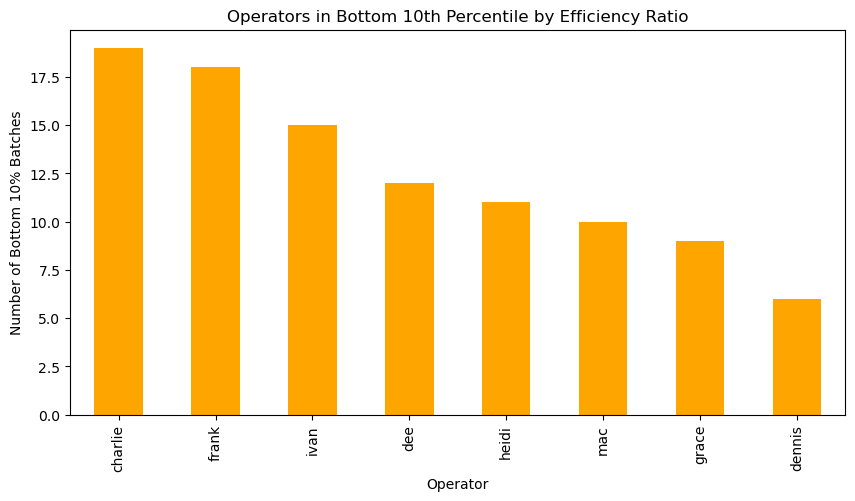

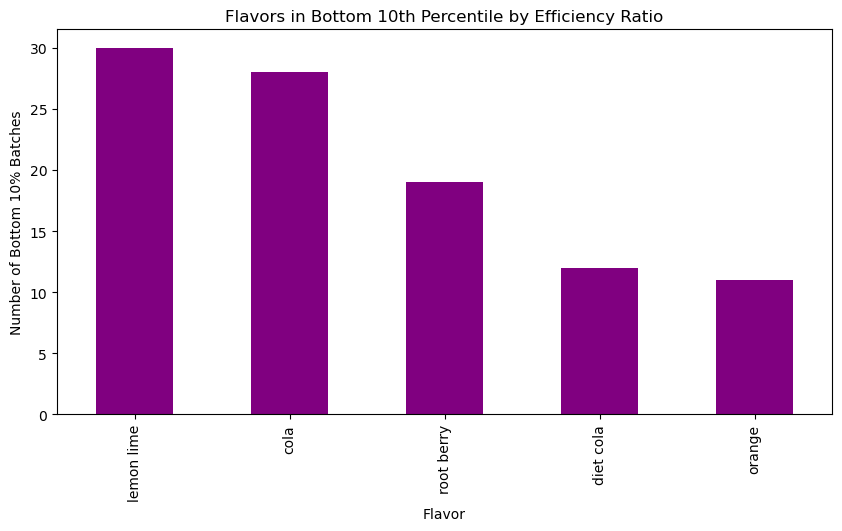

In [48]:
threshold = df['Efficiency'].quantile(0.1)
low_efficiency_batches = df[df['Efficiency'] <= threshold]
operator_low_efficiency = low_efficiency_batches['Operator'].value_counts()
flavor_low_efficiency = low_efficiency_batches['Flavor'].value_counts()

plt.figure(figsize=(10,5))
operator_low_efficiency.plot(kind='bar', color='orange')
plt.xlabel('Operator')
plt.ylabel('Number of Bottom 10% Batches')
plt.title('Operators in Bottom 10th Percentile by Efficiency Ratio')
plt.show()

plt.figure(figsize=(10,5))
flavor_low_efficiency.plot(kind='bar', color='purple')
plt.xlabel('Flavor')
plt.ylabel('Number of Bottom 10% Batches')
plt.title('Flavors in Bottom 10th Percentile by Efficiency Ratio')
plt.show()

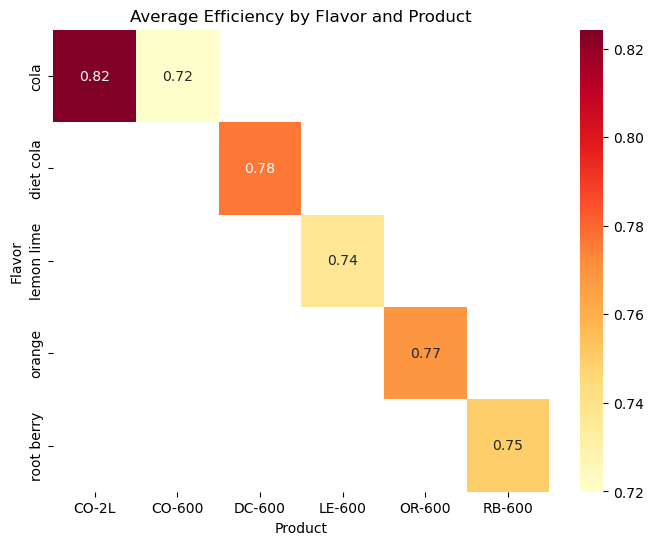

In [49]:
pivot_table = df.pivot_table(
    index='Flavor',             
    columns='Product',         
    values='Efficiency',        
    aggfunc='mean'           
)

# رسم Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap='YlOrRd')
plt.title('Average Efficiency by Flavor and Product')
plt.xlabel('Product')
plt.ylabel('Flavor')
plt.show()

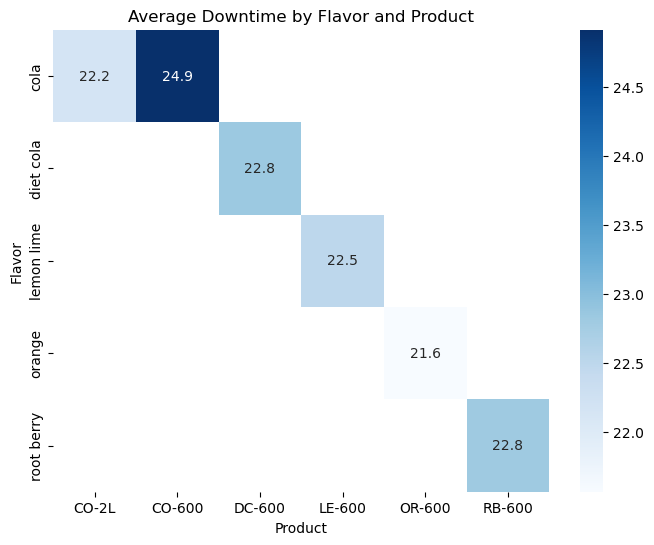

In [50]:
pivot_table_dt = df.pivot_table(
    index='Flavor',
    columns='Product',
    values='Downtime_Minutes',
    aggfunc='mean'
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table_dt, annot=True, fmt=".1f", cmap='Blues')
plt.title('Average Downtime by Flavor and Product')
plt.xlabel('Product')
plt.ylabel('Flavor')
plt.show()


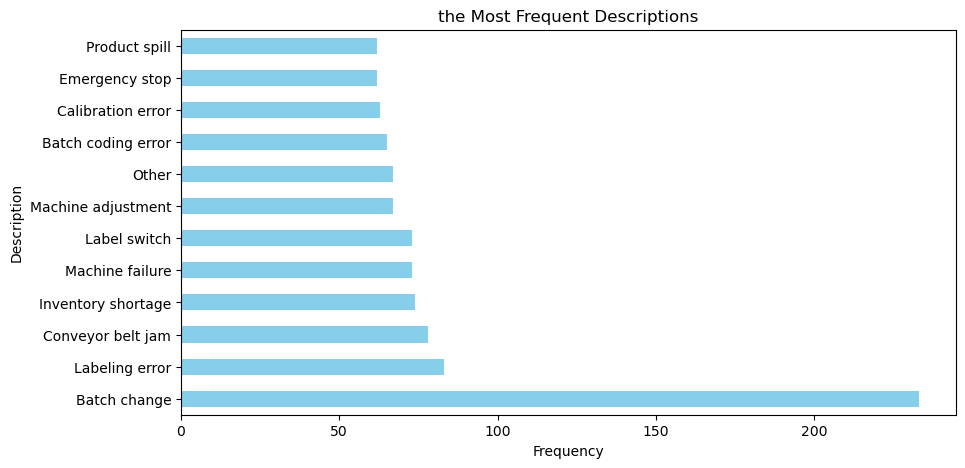

In [51]:
desc_freq = df['Description'].value_counts()
plt.figure(figsize=(10,5))
desc_freq.plot(kind='barh', color='skyblue')
plt.ylabel('Description')
plt.xlabel('Frequency')
plt.title('the Most Frequent Descriptions')
plt.xticks(rotation=0)
plt.show()

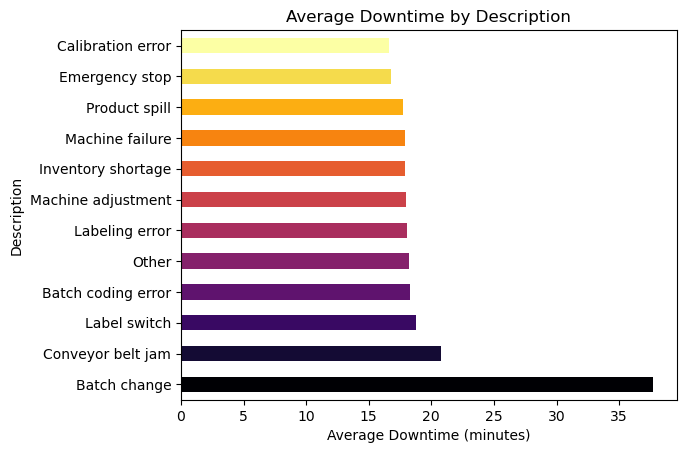

In [52]:
df.groupby("Description")['Downtime_Minutes'].mean().sort_values(ascending=False).plot(kind='barh', color=plt.cm.inferno(np.linspace(0, 1, len(df['Description'].unique()))))
plt.xlabel('Average Downtime (minutes)')
plt.ylabel('Description')
plt.title('Average Downtime by Description')
plt.show()

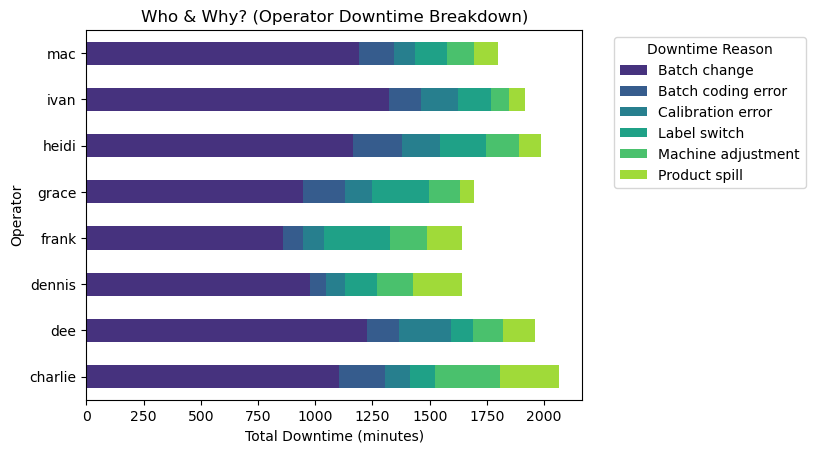

In [53]:
df.loc[df['Operator_Error']== 1].groupby(['Operator','Description'])['Downtime_Minutes'].sum().sort_values(ascending=False).unstack().plot(kind='barh',stacked=True, color=sns.color_palette("viridis", 6))
plt.xlabel('Total Downtime (minutes)')
plt.ylabel('Operator')
plt.title('Who & Why? (Operator Downtime Breakdown)')
plt.legend(title='Downtime Reason', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

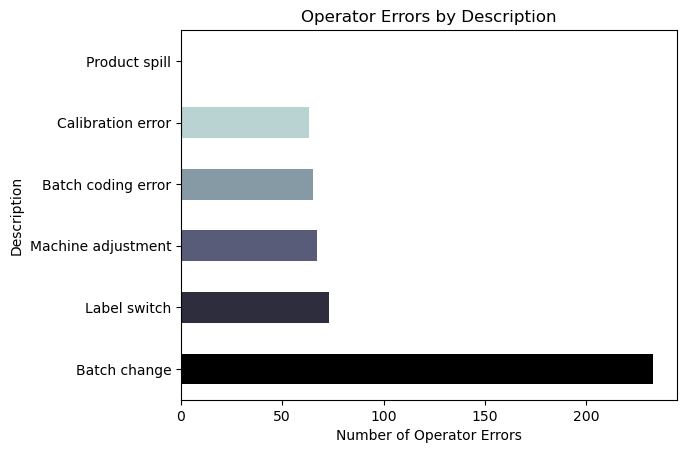

In [54]:
# count descriptions where an operator error occurred, then plot
desc_counts = df.loc[df['Operator_Error'] == 1, 'Description'].value_counts()
colors = plt.cm.bone(np.linspace(0, 1, len(desc_counts)))
desc_counts.plot(kind='barh', color=colors)
plt.xlabel('Number of Operator Errors')
plt.ylabel('Description')
plt.title('Operator Errors by Description')
plt.show()

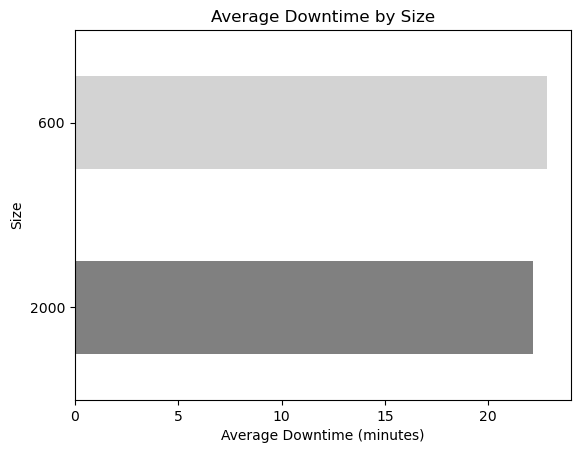

In [55]:
df.groupby("Size_ml")["Downtime_Minutes"].mean().sort_values().plot(kind='barh', color= ['gray','lightgray'])
plt.xlabel('Average Downtime (minutes)')
plt.ylabel("Size")
plt.title('Average Downtime by Size')
plt.show()

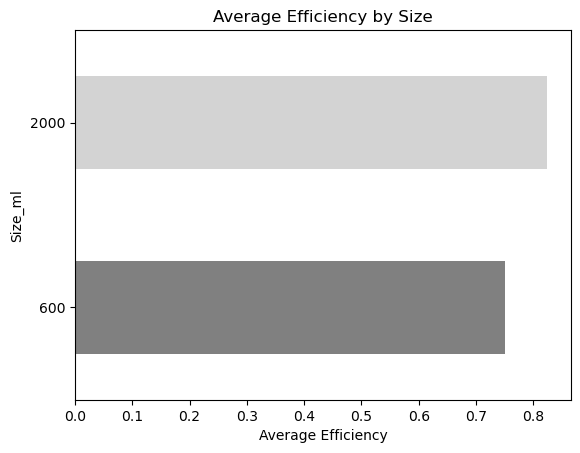

In [56]:
df.groupby("Size_ml")["Efficiency"].mean().sort_values().plot(kind='barh', color= ['gray','lightgray'])
plt.xlabel('Average Efficiency')
plt.ylabel('Size_ml')
plt.title('Average Efficiency by Size')
plt.show()

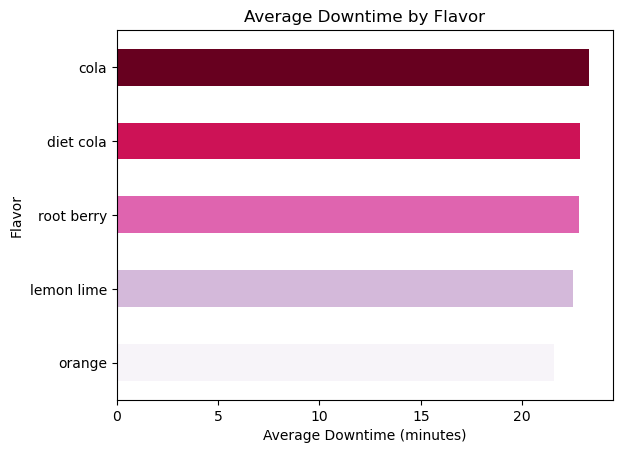

In [57]:
df.groupby("Flavor")["Downtime_Minutes"].mean().sort_values().plot(kind='barh', color= plt.cm.PuRd(np.linspace(0, 1, len(df['Flavor'].unique()))))
plt.xlabel('Average Downtime (minutes)')
plt.ylabel('Flavor')
plt.title('Average Downtime by Flavor')
plt.show()

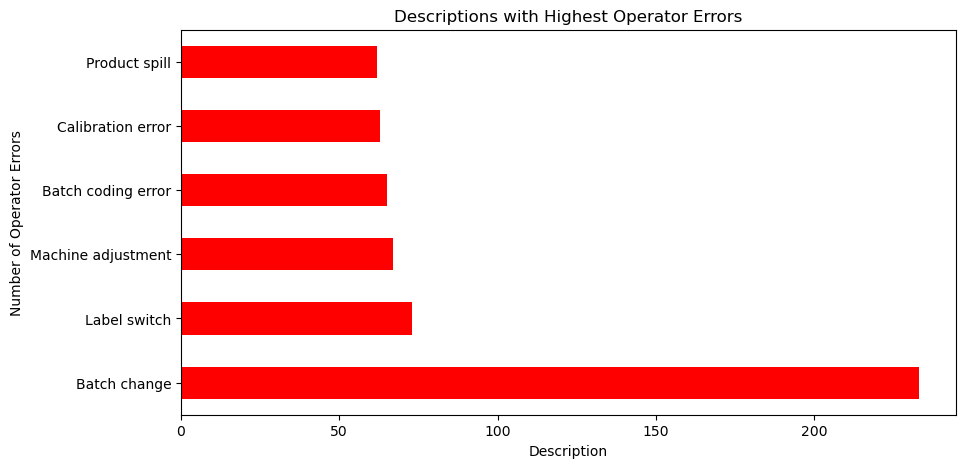

In [58]:
desc_operator_error_counts = df.loc[df['Operator_Error'] == 1, 'Description'].value_counts()
plt.figure(figsize=(10,5))
desc_operator_error_counts.plot(kind='barh', color='red')
plt.xlabel('Description')
plt.ylabel('Number of Operator Errors')
plt.title('Descriptions with Highest Operator Errors')
plt.show()

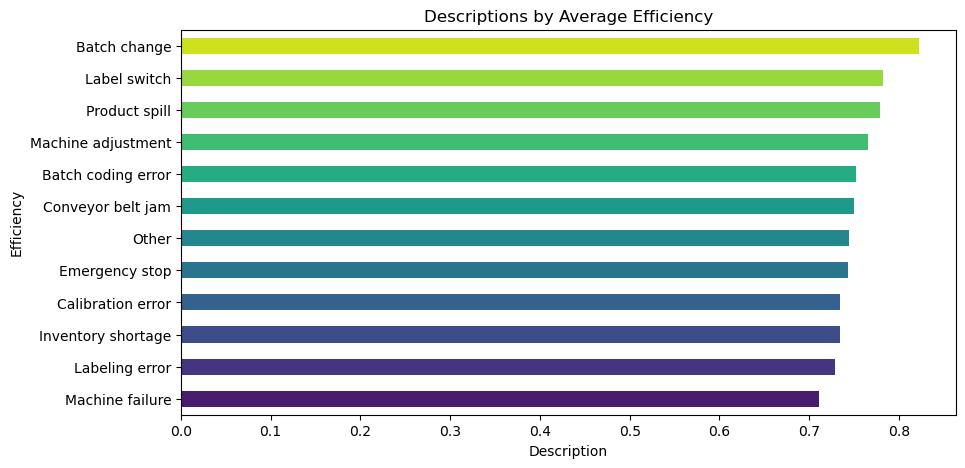

In [59]:
desc_efficiency = df.groupby('Description')['Efficiency'].mean().sort_values()
plt.figure(figsize=(10,5))
desc_efficiency.plot(kind='barh', color=sns.color_palette("viridis", len(desc_efficiency)))
plt.xlabel('Description')
plt.ylabel('Efficiency')
plt.title('Descriptions by Average Efficiency')
plt.show()

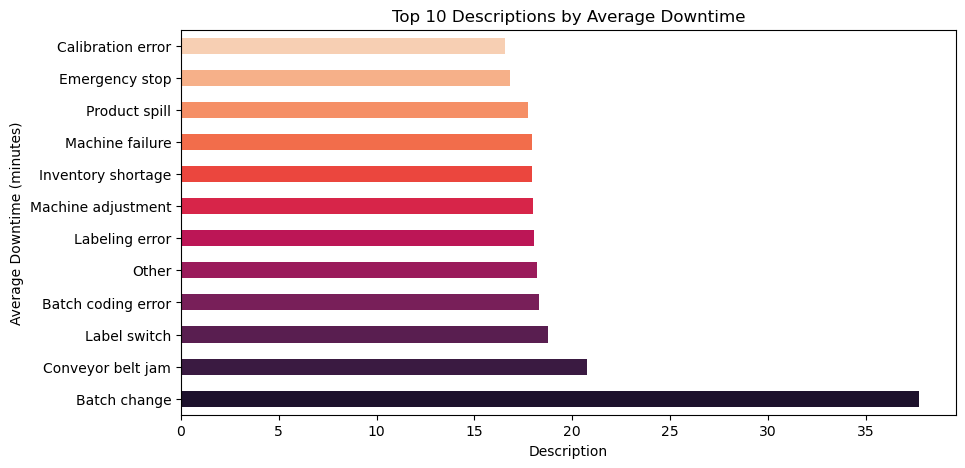

In [60]:
desc_downtime = df.groupby('Description')['Downtime_Minutes'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
desc_downtime.plot(kind='barh', color=sns.color_palette("rocket", len(desc_downtime)))
plt.xlabel('Description')
plt.ylabel('Average Downtime (minutes)')
plt.title('Top 10 Descriptions by Average Downtime')

plt.show()

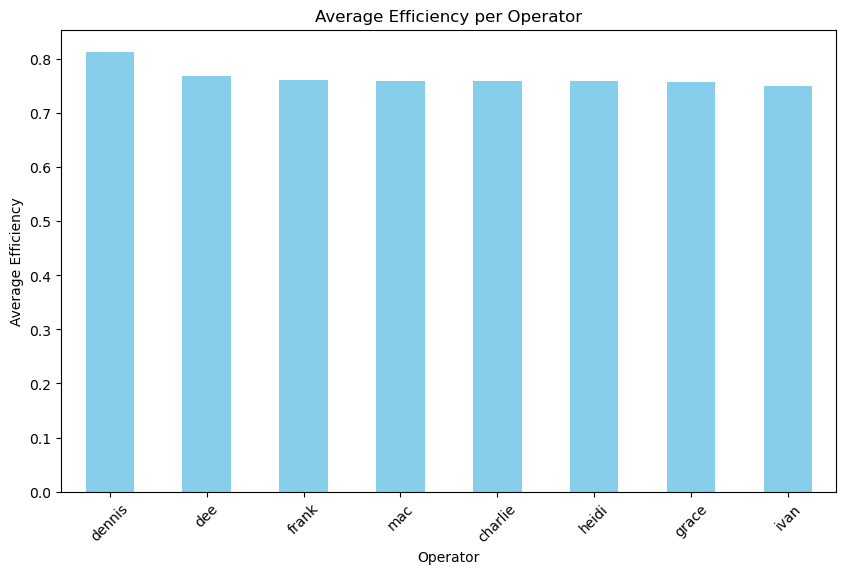

In [61]:
operator_efficiency = df.groupby('Operator')['Efficiency'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
operator_efficiency.plot(kind='bar', color='skyblue')
plt.xlabel('Operator')
plt.ylabel('Average Efficiency')
plt.title('Average Efficiency per Operator')
plt.xticks(rotation=45)
plt.show()

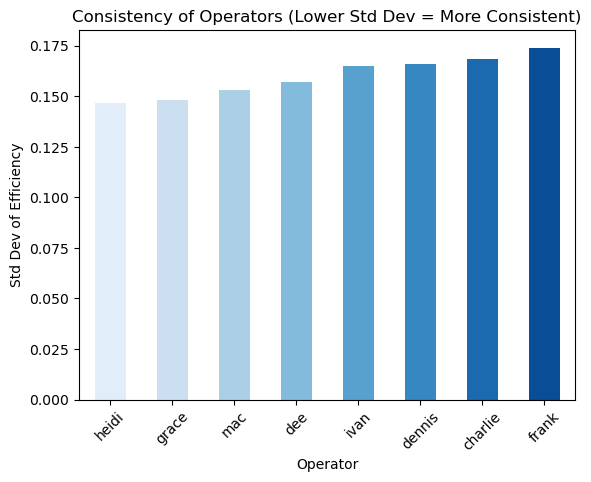

In [62]:
# Who is the most consistent operator, based on the lowest standard deviation in efficiency_ratio?
operator_std = df.groupby('Operator')['Efficiency'].std().sort_values()
operator_std.plot(kind='bar', color=sns.color_palette("Blues", len(operator_std)))
plt.xlabel('Operator')
plt.ylabel('Std Dev of Efficiency')
plt.title('Consistency of Operators (Lower Std Dev = More Consistent)')
plt.xticks(rotation=45)
plt.show()

Text(0.5, 1.0, 'Average Performance Loss by Product')

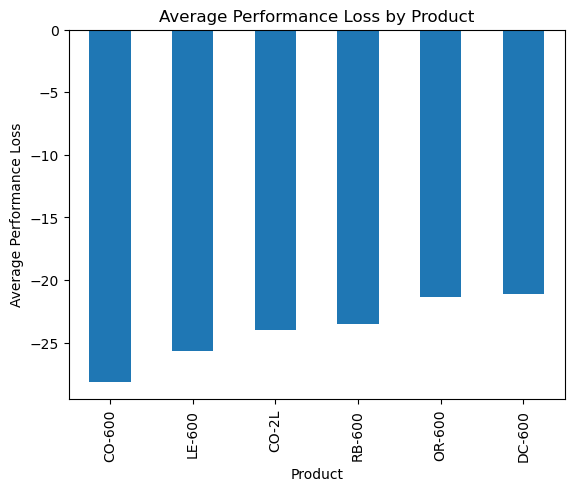

In [63]:
df.groupby("Product")["Performance_loss"].mean().sort_values().plot(kind='bar')
plt.xlabel('Product')
plt.ylabel('Average Performance Loss')
plt.title('Average Performance Loss by Product')

<Axes: ylabel='Operator'>

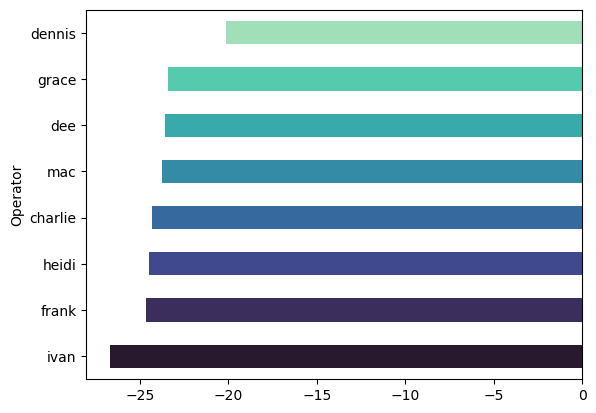

In [64]:
df.groupby("Operator")['Performance_loss'].mean().sort_values().plot(kind='barh', color=sns.color_palette("mako", len(df['Operator'].unique())))

<Axes: ylabel='Description'>

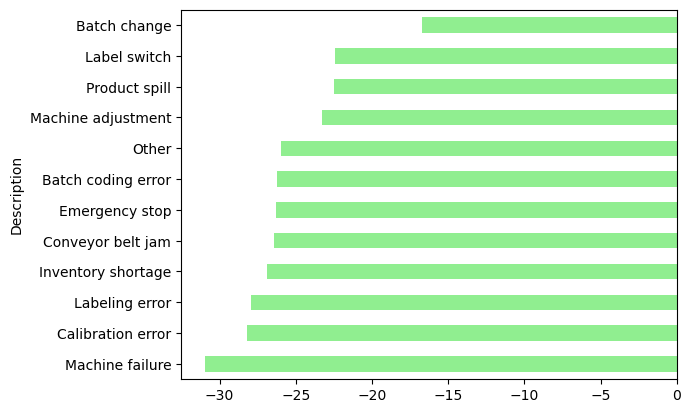

In [65]:
df.groupby("Description")['Performance_loss'].mean().sort_values().plot(kind='barh', color='lightgreen')

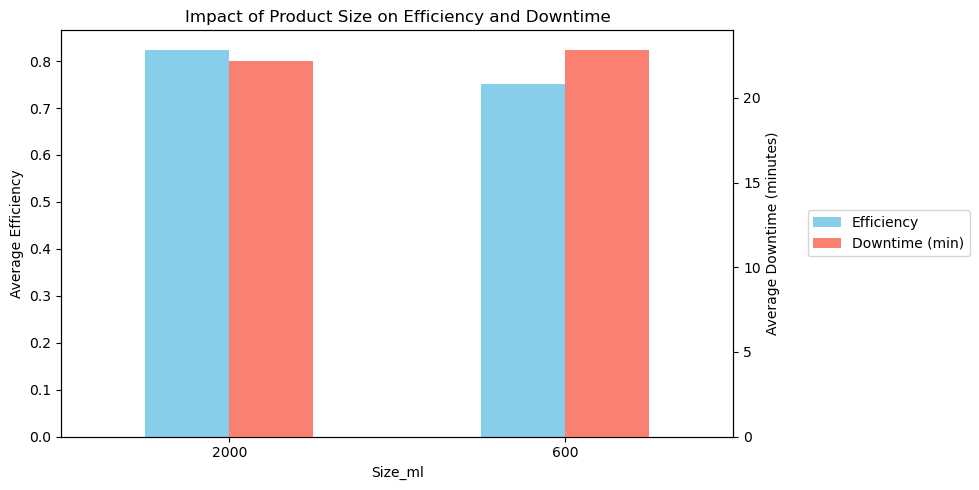

In [66]:
from matplotlib.patches import Patch

size_analysis = df.groupby('Size_ml')[['Efficiency', 'Downtime_Minutes']].mean().sort_values(by='Efficiency', ascending=False)
# let pandas return the axes object so we can access the secondary axis via ax.right_ax
ax = size_analysis.plot(kind='bar', secondary_y='Downtime_Minutes', color=['skyblue', 'salmon'], figsize=(10,5),legend=False)
ax.set_xlabel('Size_ml')
ax.set_ylabel('Average Efficiency')
ax.set_title('Impact of Product Size on Efficiency and Downtime')
# set label for the secondary (right) y-axis
ax.right_ax.set_ylabel('Average Downtime (minutes)')
# keep x tick labels horizontal
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
handles = [Patch(facecolor='skyblue', label='Efficiency'), Patch(facecolor='salmon', label='Downtime (min)')]
ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1.1, 0.5))
plt.tight_layout()
plt.show()

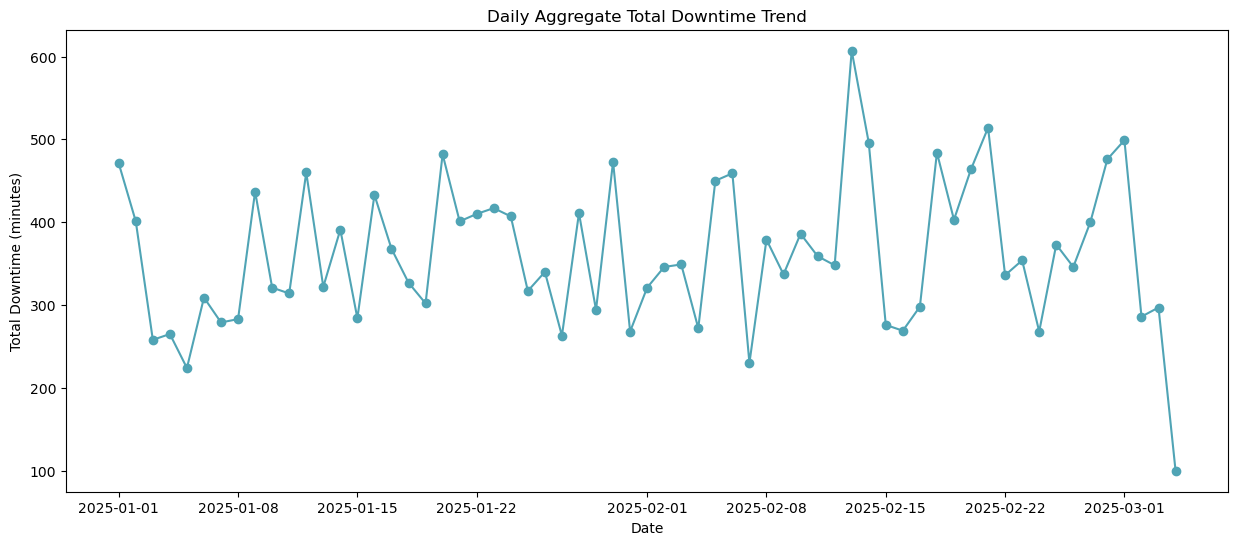

In [67]:
# تحويل العمود Date إلى datetime
df['Date'] = pd.to_datetime(df['Date'])

# حساب إجمالي Downtime لكل يوم
daily_downtime = df.groupby('Date')['Downtime_Minutes'].sum().sort_index()

# رسم Time-Series Line Chart
plt.figure(figsize=(15,6))
plt.plot(daily_downtime.index, daily_downtime.values, color="#50A4B5", marker='o')
plt.xlabel('Date')
plt.ylabel('Total Downtime (minutes)')
plt.title('Daily Aggregate Total Downtime Trend')
plt.show()

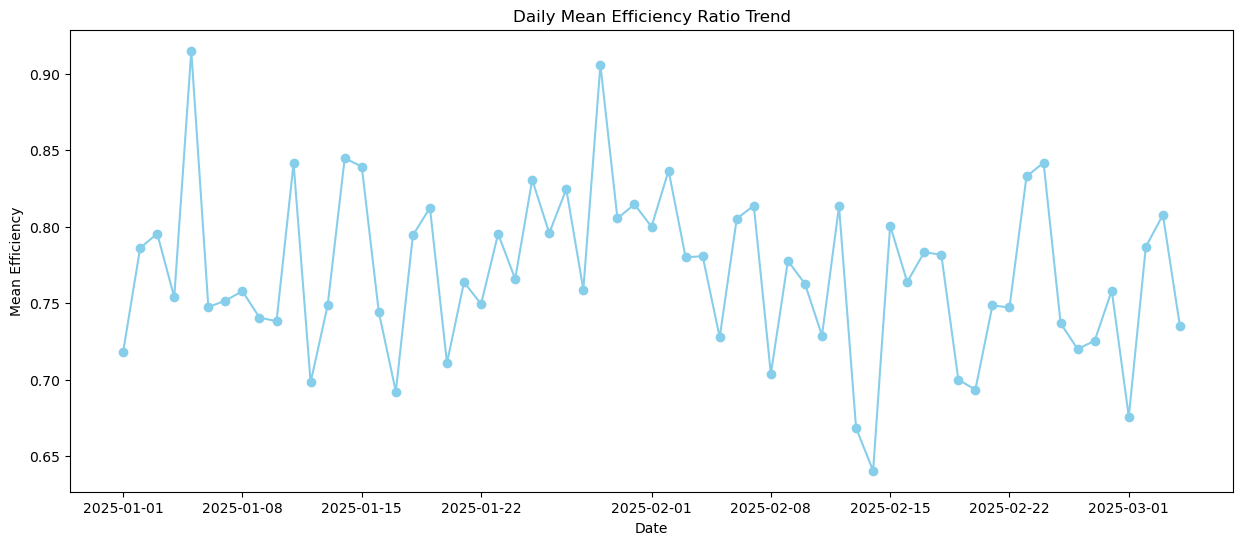

In [68]:
# حساب متوسط Efficiency لكل يوم
daily_efficiency = df.groupby('Date')['Efficiency'].mean().sort_index()

# رسم Time-Series Line Chart
plt.figure(figsize=(15,6))
plt.plot(daily_efficiency.index, daily_efficiency.values, color='skyblue', marker='o')
plt.xlabel('Date')
plt.ylabel('Mean Efficiency')
plt.title('Daily Mean Efficiency Ratio Trend')
plt.show()

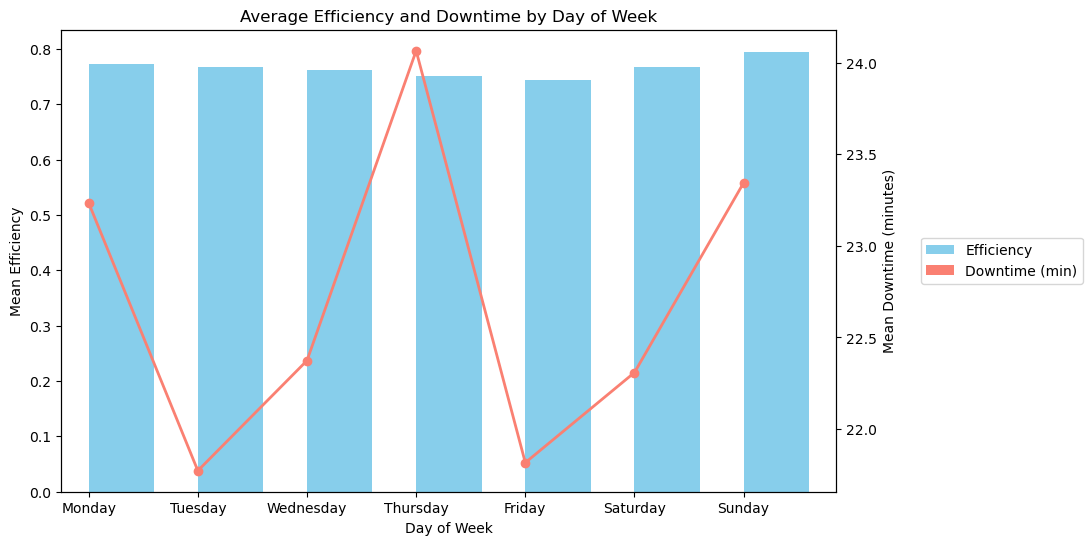

In [69]:
# استخراج يوم الأسبوع (0 = Monday, 6 = Sunday)
df['Day_of_Week'] = df['Date'].dt.day_name()  # يعطي اسم اليوم مباشرة

# حساب متوسط Efficiency و Downtime لكل يوم
dow_day_analysis = df.groupby('Day_of_Week')[['Efficiency', 'Downtime_Minutes']].mean()

# ترتيب الأيام حسب التسلسل الأسبوعي
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_day_analysis = dow_day_analysis.reindex(dow_order)

# رسم: نرسم Efficiency كأعمدة ونرسم Downtime على المحور الثانوي كخط لتفادي مشكلات right_ax
ax = dow_day_analysis['Efficiency'].plot(kind='bar', color='skyblue', figsize=(10,6), width=0.6, position=0)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Mean Efficiency')

# إنشاء محور ثانوي باستخدام twinx() ثم رسم Downtime عليه (كمخط)
ax2 = ax.twinx()
dow_day_analysis['Downtime_Minutes'].plot(kind='line', ax=ax2, color='salmon', marker='o', linewidth=2)
ax2.set_ylabel('Mean Downtime (minutes)')
handles = [Patch(facecolor='skyblue', label='Efficiency'), Patch(facecolor='salmon', label='Downtime (min)')]
ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1.1, 0.5))
plt.title('Average Efficiency and Downtime by Day of Week')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.show()

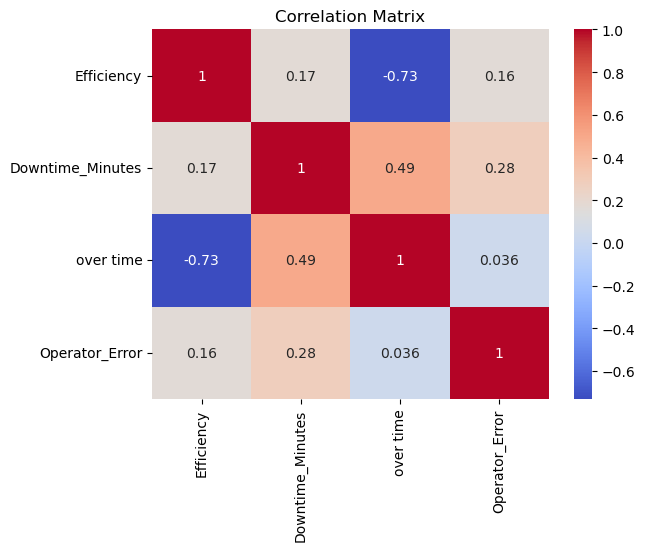

In [70]:
df[['Efficiency','Downtime_Minutes','over time','Operator_Error']].corr()
sns.heatmap(df[['Efficiency','Downtime_Minutes','over time','Operator_Error']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

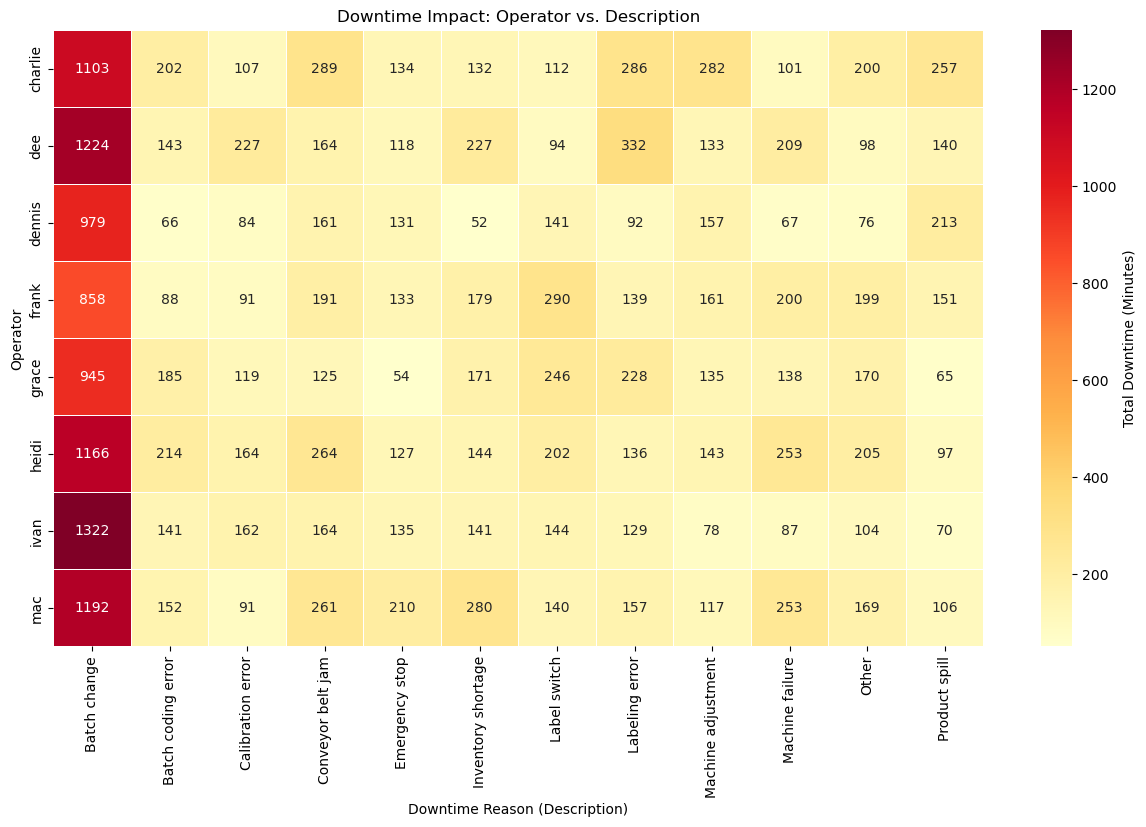

In [71]:
downtime_pivot = df.pivot_table(
    index='Operator',
    columns='Description',
    values='Downtime_Minutes',
    aggfunc='sum' # نجمع دقائق التوقف
)

# 2. إنشاء خريطة الحرارة
plt.figure(figsize=(15, 8))
sns.heatmap(
    downtime_pivot,
    annot=True,    # لإظهار الأرقام داخل الخلايا
    fmt=".0f",     # تنسيق الأرقام كأعداد صحيحة
    cmap="YlOrRd", # تدرج لوني من الأصفر (قليل) إلى الأحمر الداكن (كثير)
    linewidths=.5, # خطوط فاصلة
    cbar_kws={'label': 'Total Downtime (Minutes)'}
)
plt.title('Downtime Impact: Operator vs. Description')
plt.ylabel('Operator')
plt.xlabel('Downtime Reason (Description)')
plt.show()

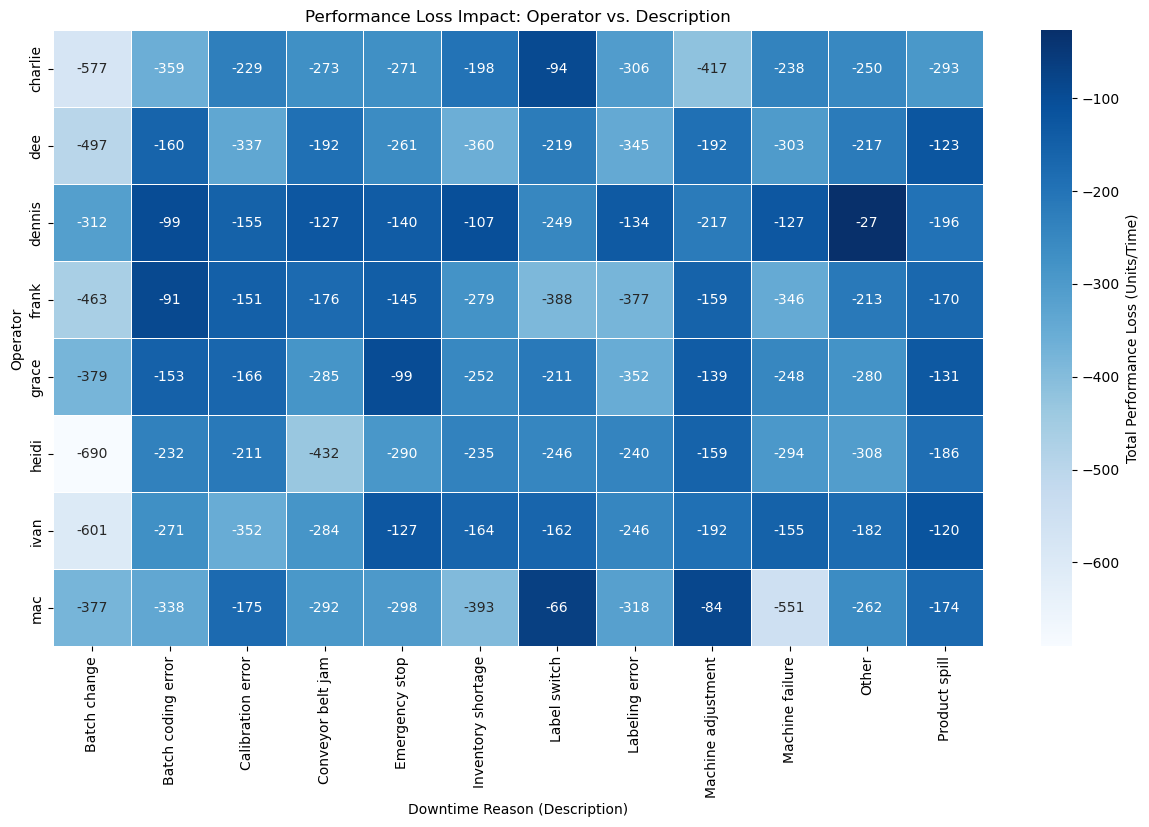

In [72]:
loss_pivot = df.pivot_table(
    index='Operator',
    columns='Description',
    values='Performance_loss', # العمود الجديد
    aggfunc='sum'
)

# 2. إنشاء خريطة الحرارة
plt.figure(figsize=(15, 8))
# نستخدم cmap مختلف قد يكون أزرق/أبيض
sns.heatmap(
    loss_pivot,
    annot=True,
    fmt=".0f",
    cmap="Blues", # تدرج لوني يعبر عن "الخسارة" (Loss)
    linewidths=.5,
    cbar_kws={'label': 'Total Performance Loss (Units/Time)'}
)
plt.title('Performance Loss Impact: Operator vs. Description')
plt.ylabel('Operator')
plt.xlabel('Downtime Reason (Description)')
plt.show()